In [ ]:
# ============================================================
# Cell 0: Mounts Google Drive so the notebook can access result files stored in Drive.
# Keep the original execution order: run prerequisite cells first so shared variables are available.
# ============================================================

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# ============================================================
# Cell 1: Loads and merges the res_report files, prepares the numeric score matrix, computes paired-t distances, and runs K-Medoids clustering.
# Keep the original execution order: run prerequisite cells first so shared variables are available.
# ============================================================

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


RESULTS_DIR = Path("/content/drive/MyDrive/deep_imposters_final_project/hebrew_results/")

LAST_ITERATION_BEFORE_CRASH = 49

LAST_ITERATION_AFTER_RESUME = 90

LSTM_UNITS = 1200

START_EVOLUTION_ITERATION = 10

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


SHOW_NAMES_ON_GRAPHS = True

MATRIX_FIGSIZE = (30, 28)
EVOLUTION_FIGSIZE = (24, 36)

AXIS_LABEL_FONT_SIZE = 4
EVOLUTION_AXIS_LABEL_FONT_SIZE = 5


def chapter_to_book(chapter_name: str) -> str:
    """Helper function used by this cell."""
    return str(chapter_name).split("_CH")[0]


def get_iteration_columns(df: pd.DataFrame):
    """Helper function used by this cell."""
    return [col for col in df.columns if col != "Names"]


def convert_iteration_columns_to_int(columns):
    """Helper function used by this cell."""
    result = []

    for col in columns:
        try:
            result.append(int(str(col)))
        except ValueError:
            raise ValueError(f"Found a non-numeric iteration column: {col}")

    return result


def check_columns_sequence(
    columns_as_int,
    expected_start=None,
    expected_end=None,
    label=""
):
    """Helper function used by this cell."""
    sorted_cols = sorted(columns_as_int)

    if expected_start is None:
        expected_start = sorted_cols[0]

    if expected_end is None:
        expected_end = sorted_cols[-1]

    expected = list(range(expected_start, expected_end + 1))

    missing = sorted(set(expected) - set(sorted_cols))
    extra = sorted(set(sorted_cols) - set(expected))

    print(f"\nColumn sequence check for: {label}")
    print("First column:", sorted_cols[0])
    print("Last column:", sorted_cols[-1])
    print("Number of columns:", len(sorted_cols))

    if missing:
        print("Missing columns:", missing)
    else:
        print("No columns are missing in the expected range.")

    if extra:
        print("Unexpected columns:", extra)
    else:
        print("No out-of-range columns were found.")

    return missing, extra


def load_res_report(results_dir: Path, iteration: int, lstm_units: int):
    """Helper function used by this cell."""
    file_path = results_dir / f"res_report_{iteration}_{lstm_units}.csv"

    if not file_path.exists():
        raise FileNotFoundError(f"File not found:\n{file_path}")

    df = pd.read_csv(file_path)

    if "Names" not in df.columns:
        raise ValueError(f"The file must contain a Names column in:\n{file_path.name}")

    return df, file_path


def build_final_df_from_resume_files(
    results_dir: Path,
    last_iteration_before_crash: int,
    last_iteration_after_resume: int,
    lstm_units: int
):
    """Helper function used by this cell."""

    before_df, before_file = load_res_report(
        results_dir,
        last_iteration_before_crash,
        lstm_units
    )

    after_df, after_file = load_res_report(
        results_dir,
        last_iteration_after_resume,
        lstm_units
    )

    print("Loaded pre-crash file:")
    print(before_file.name)
    print("shape:", before_df.shape)

    print("\nLoaded resumed-run file:")
    print(after_file.name)
    print("shape:", after_df.shape)


    before_columns = get_iteration_columns(before_df)
    after_columns = get_iteration_columns(after_df)

    before_iters = convert_iteration_columns_to_int(before_columns)
    after_iters = convert_iteration_columns_to_int(after_columns)

    check_columns_sequence(
        before_iters,
        expected_start=1,
        expected_end=last_iteration_before_crash,
        label="before crash"
    )

    check_columns_sequence(
        after_iters,
        expected_start=last_iteration_before_crash + 1,
        expected_end=last_iteration_after_resume,
        label="after resume"
    )


    before_names = set(before_df["Names"].astype(str))
    after_names = set(after_df["Names"].astype(str))

    only_before = sorted(before_names - after_names)
    only_after = sorted(after_names - before_names)

    print("\nChapter alignment check:")
    print("Number of chapters before crash:", len(before_names))
    print("Number of chapters after resume:", len(after_names))

    if only_before:
        print("Chapters appearing only before crash:")
        print(only_before[:20])
    else:
        print("No chapters appear only before crash.")

    if only_after:
        print("Chapters appearing only after resume:")
        print(only_after[:20])
    else:
        print("No chapters appear only after resume.")


    merged_df = before_df.merge(
        after_df,
        on="Names",
        how="inner",
        suffixes=("_before", "_after")
    )

    print("\nAfter merging:")
    print("shape:", merged_df.shape)


    iteration_columns = get_iteration_columns(merged_df)
    clean_column_map = {}

    for col in iteration_columns:
        col_str = str(col)

        if col_str.isdigit():
            clean_column_map[col] = int(col_str)

        else:
            match = re.match(r"^(\d+)_(before|after)$", col_str)

            if match:
                clean_column_map[col] = int(match.group(1))
            else:
                raise ValueError(f"Unrecognized column after the merge: {col}")

    iteration_numbers = list(clean_column_map.values())

    duplicates = sorted([
        x for x in set(iteration_numbers)
        if iteration_numbers.count(x) > 1
    ])

    if duplicates:
        raise ValueError(
            f"Duplicate iterations were found after the merge: {duplicates}\n"
            "This means the pre-crash file and the resumed-run file overlap."
        )

    sorted_original_columns = sorted(
        clean_column_map.keys(),
        key=lambda col: clean_column_map[col]
    )

    sorted_iteration_numbers = [
        clean_column_map[col]
        for col in sorted_original_columns
    ]

    expected_all_iterations = list(range(1, last_iteration_after_resume + 1))
    missing_after_merge = sorted(
        set(expected_all_iterations) - set(sorted_iteration_numbers)
    )

    print("\nSequence check after merging:")
    print("First column:", sorted_iteration_numbers[0])
    print("Last column:", sorted_iteration_numbers[-1])
    print("Number of run columns after merging:", len(sorted_iteration_numbers))

    if missing_after_merge:
        print("Iterations are still missing after merging:")
        print(missing_after_merge)
    else:
        print("All iterations are present after merging.")


    final_df = merged_df[["Names"] + sorted_original_columns].copy()

    rename_columns = {
        col: str(clean_column_map[col])
        for col in sorted_original_columns
    }

    final_df = final_df.rename(columns=rename_columns)

    print("\nFinal merged table:")
    print("shape:", final_df.shape)
    print("First columns:", final_df.columns[:10].tolist())
    print("Last columns:", final_df.columns[-10:].tolist())

    display(final_df.head())

    return final_df


def prepare_scores_from_final_df(final_df: pd.DataFrame):
    """Helper function used by this cell."""

    if "Names" not in final_df.columns:
        raise ValueError("final_df must contain a Names column.")

    chapter_names = final_df["Names"].astype(str).reset_index(drop=True)

    score_columns = [col for col in final_df.columns if col != "Names"]
    score_columns = sorted(score_columns, key=lambda c: int(str(c)))

    scores_df = final_df[score_columns].apply(pd.to_numeric, errors="coerce")

    missing_values = scores_df.isna().sum().sum()

    print("\nMissing-value check:")
    print("Number of missing values:", missing_values)

    if missing_values > 0:
        print("Filling missing values using column means.")
        scores_df = scores_df.fillna(scores_df.mean())

    X = scores_df.values

    print("\nScore matrix:")
    print("Number of chapters:", X.shape[0])
    print("Number of iterations:", X.shape[1])

    return chapter_names, score_columns, scores_df, X


def paired_t_distance_matrix(X):
    """Helper function used by this cell."""

    X = np.asarray(X, dtype=float)
    n_docs, n_features = X.shape

    dist = np.zeros((n_docs, n_docs), dtype=float)

    for i in range(n_docs):
        for j in range(i + 1, n_docs):

            diff = X[i] - X[j]

            mean_diff = np.mean(diff)
            std_diff = np.std(diff, ddof=1)

            if std_diff == 0 or np.isnan(std_diff):
                if abs(mean_diff) < 1e-12:
                    t_value = 0.0
                else:
                    t_value = 1e6
            else:
                t_value = mean_diff / (std_diff / np.sqrt(n_features))

            distance = abs(t_value)

            dist[i, j] = distance
            dist[j, i] = distance

    np.fill_diagonal(dist, 0.0)

    return dist


def simple_kmedoids_precomputed(
    distance_matrix,
    n_clusters=2,
    max_iter=100,
    random_state=42
):
    """Helper function used by this cell."""

    rng = np.random.default_rng(random_state)
    n = distance_matrix.shape[0]

    medoids = rng.choice(n, size=n_clusters, replace=False)

    for _ in range(max_iter):

        distances_to_medoids = distance_matrix[:, medoids]
        labels = np.argmin(distances_to_medoids, axis=1)

        new_medoids = medoids.copy()

        for cluster_id in range(n_clusters):

            members = np.where(labels == cluster_id)[0]

            if len(members) == 0:
                new_medoids[cluster_id] = rng.integers(0, n)
                continue

            intra_distances = distance_matrix[np.ix_(members, members)]
            total_distances = intra_distances.sum(axis=1)

            best_member = members[np.argmin(total_distances)]
            new_medoids[cluster_id] = best_member

        if np.array_equal(medoids, new_medoids):
            break

        medoids = new_medoids

    final_distances = distance_matrix[:, medoids]
    labels = np.argmin(final_distances, axis=1)

    return labels, medoids


def align_labels_small_cluster_is_1(labels):
    """Helper function used by this cell."""

    labels = np.asarray(labels)

    unique, counts = np.unique(labels, return_counts=True)

    if len(unique) != 2:
        raise ValueError("Exactly two clusters are required.")

    small_cluster = unique[np.argmin(counts)]
    large_cluster = unique[np.argmax(counts)]

    aligned = np.where(labels == small_cluster, 1, 2)

    return aligned


def cluster_score_vectors(X, random_state=42):
    """Helper function used by this cell."""

    distance_matrix = paired_t_distance_matrix(X)

    raw_labels, medoids = simple_kmedoids_precomputed(
        distance_matrix,
        n_clusters=2,
        random_state=random_state
    )

    aligned_labels = align_labels_small_cluster_is_1(raw_labels)

    return aligned_labels, distance_matrix, medoids


def set_all_chapter_ticks(chapter_labels, x_axis=True, y_axis=True, font_size=4):
    """Helper function used by this cell."""

    positions = np.arange(len(chapter_labels))

    if x_axis:
        plt.xticks(
            positions,
            chapter_labels,
            rotation=90,
            fontsize=font_size
        )

    if y_axis:
        plt.yticks(
            positions,
            chapter_labels,
            fontsize=font_size
        )


final_df = build_final_df_from_resume_files(
    results_dir=RESULTS_DIR,
    last_iteration_before_crash=LAST_ITERATION_BEFORE_CRASH,
    last_iteration_after_resume=LAST_ITERATION_AFTER_RESUME,
    lstm_units=LSTM_UNITS
)

chapter_names, score_columns, scores_df, X = prepare_scores_from_final_df(final_df)

n_documents, n_iterations = X.shape

straight_labels, full_distance_matrix, full_medoids = cluster_score_vectors(
    X,
    random_state=RANDOM_STATE
)

straight_is_suspicious = (straight_labels == 1).astype(int)

analysis_df = pd.DataFrame({
    "chapter": chapter_names,
    "book": chapter_names.apply(chapter_to_book),
    "mean_anomaly_score": scores_df.mean(axis=1),
    "median_anomaly_score": scores_df.median(axis=1),
    "min_anomaly_score": scores_df.min(axis=1),
    "negative_count": (scores_df < 0).sum(axis=1),
    "negative_ratio": (scores_df < 0).mean(axis=1),
    "straight_label": straight_labels,
    "straight_suspicious": straight_is_suspicious,
})

print("\nK-Medoids summary across all iterations:")
print("Number of suspicious / smaller-cluster chapters:", int(straight_is_suspicious.sum()))
print("Number of core / larger-cluster chapters:", int(len(straight_is_suspicious) - straight_is_suspicious.sum()))

print("\nChapters assigned to the smaller K-Medoids cluster:")
display(
    analysis_df[analysis_df["straight_label"] == 1]
    .sort_values(["negative_count", "mean_anomaly_score"], ascending=[False, True])
)


Loaded pre-crash file:
res_report_49_1200.csv
shape: (183, 50)

Loaded resumed-run file:
res_report_90_1200.csv
shape: (183, 42)

Column sequence check for: before crash
First column: 1
Last column: 49
Number of columns: 49
No columns are missing in the expected range.
No out-of-range columns were found.

Column sequence check for: after resume
First column: 50
Last column: 90
Number of columns: 41
No columns are missing in the expected range.
No out-of-range columns were found.

Chapter alignment check:
Number of chapters before crash: 183
Number of chapters after resume: 183
No chapters appear only before crash.
No chapters appear only after resume.

After merging:
shape: (183, 91)

Sequence check after merging:
First column: 1
Last column: 90
Number of run columns after merging: 90
All iterations are present after merging.

Final merged table:
shape: (183, 91)
First columns: ['Names', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Last columns: ['81', '82', '83', '84', '85', '86', '87

,Names,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,Bamidbar_CH1,-0.133268,0.050742,0.168160,0.063596,0.165492,0.055427,0.073067,0.001283,0.011326,...,0.032180,0.007775,0.035121,0.136372,-0.216678,-0.146964,0.063555,0.119552,0.063394,0.053387
1,Bamidbar_CH10,-0.047510,0.111803,0.175406,0.151706,-0.035402,0.076133,0.087375,0.152539,0.174363,...,0.146461,0.140359,0.084896,0.134566,0.202155,0.102074,0.158894,0.186684,0.045864,0.073479
2,Bamidbar_CH11,0.127371,0.156205,0.137915,0.053491,0.082573,0.050575,0.082639,-0.073540,0.169756,...,0.034205,0.039770,0.004104,-0.107183,0.198187,0.050934,0.010595,0.164971,0.063872,0.069325
3,Bamidbar_CH13,0.016009,-0.030858,0.176805,0.122585,0.051871,0.086518,0.096285,0.073637,-0.069888,...,0.012870,0.073309,0.078993,0.097852,0.193764,0.094442,0.142859,0.037569,0.087542,0.067107
4,Bamidbar_CH14,0.132141,-0.002477,0.152560,0.099427,-0.014866,0.070276,0.093880,0.167946,0.135061,...,-0.024892,0.077931,-0.010006,0.122054,0.202433,0.053521,0.032928,0.158310,0.033743,0.042672



Missing-value check:
Number of missing values: 0

Score matrix:
Number of chapters: 183
Number of iterations: 90

K-Medoids summary across all iterations:
Number of suspicious / smaller-cluster chapters: 86
Number of core / larger-cluster chapters: 97

Chapters assigned to the smaller K-Medoids cluster:


,chapter,book,mean_anomaly_score,median_anomaly_score,min_anomaly_score,negative_count,negative_ratio,straight_label,straight_suspicious
22,Bamidbar_CH30,Bamidbar,0.111156,0.137233,-0.222705,11,0.122222,1,1
56,Beereshit_CH29,Beereshit,0.106350,0.117717,-0.110021,10,0.111111,1,1
35,Beereshit_CH1,Beereshit,0.111726,0.147109,-0.161750,9,0.100000,1,1
102,Dvarim_CH25,Dvarim,0.108062,0.139935,-0.220154,8,0.088889,1,1
94,Dvarim_CH18,Dvarim,0.108167,0.114895,-0.284907,8,0.088889,1,1
...,...,...,...,...,...,...,...,...,...
92,Dvarim_CH16,Dvarim,0.136650,0.159610,-0.037188,1,0.011111,1,1
38,Beereshit_CH12,Beereshit,0.136940,0.153235,-0.004947,1,0.011111,1,1
63,Beereshit_CH35,Beereshit,0.140668,0.162271,-0.050381,1,0.011111,1,1
126,Shmot_CH18,Shmot,0.128263,0.141843,0.003080,0,0.000000,1,1


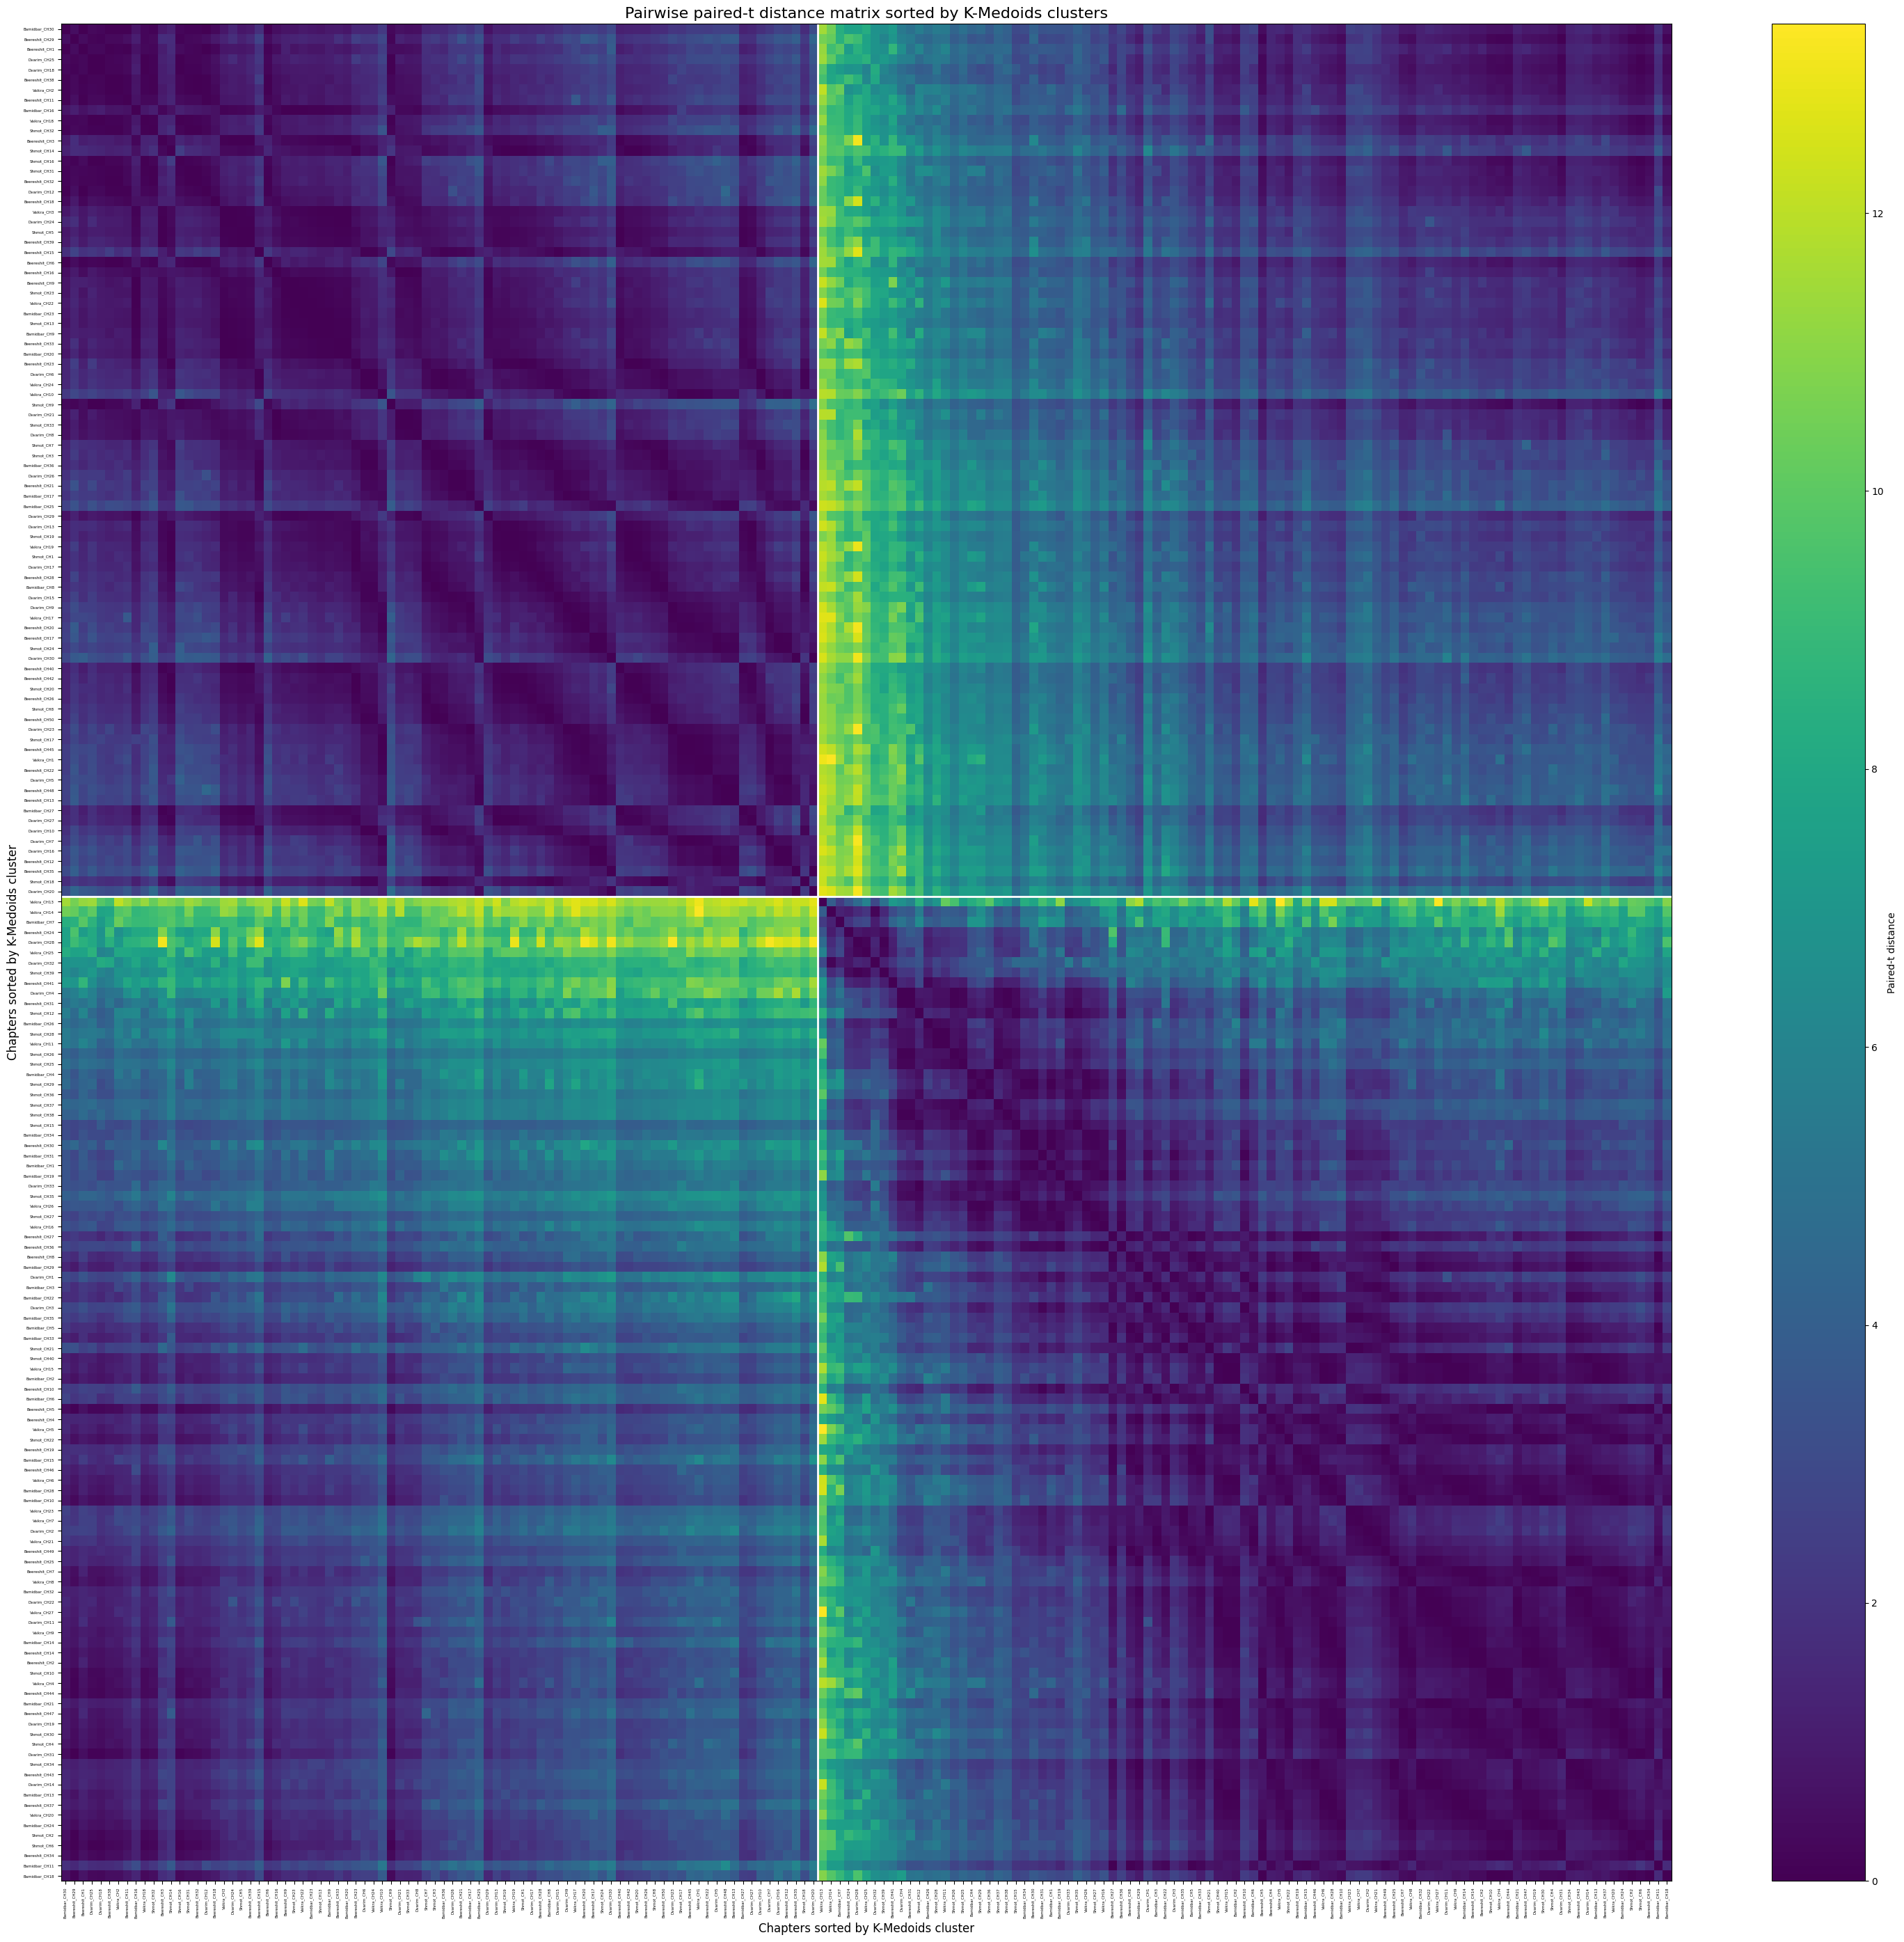

Brief interpretation:
The first block in the matrix is the smaller cluster: label 1 = suspicious.
The second block in the matrix is the larger cluster: label 2 = core.
A stronger color indicates a larger paired-t distance between chapters.

Suspicious cluster size: 86
Core cluster size: 97


,chapter,book,straight_label,negative_count,negative_ratio,mean_anomaly_score
0,Bamidbar_CH30,Bamidbar,1,11,0.122222,0.111156
1,Beereshit_CH29,Beereshit,1,10,0.111111,0.106350
2,Beereshit_CH1,Beereshit,1,9,0.100000,0.111726
3,Dvarim_CH25,Dvarim,1,8,0.088889,0.108062
4,Dvarim_CH18,Dvarim,1,8,0.088889,0.108167
...,...,...,...,...,...,...
178,Shmot_CH2,Shmot,2,7,0.077778,0.105726
179,Shmot_CH6,Shmot,2,7,0.077778,0.107247
180,Beereshit_CH34,Beereshit,2,6,0.066667,0.104484
181,Bamidbar_CH11,Bamidbar,2,5,0.055556,0.088053


In [ ]:
# ============================================================
# Cell 2: Plots the paired-t distance matrix sorted by K-Medoids cluster assignment.
# Keep the original execution order: run prerequisite cells first so shared variables are available.
# ============================================================

if "analysis_df" not in globals():
    raise RuntimeError("analysis_df was not found. Run cell 1 first.")

if "full_distance_matrix" not in globals():
    raise RuntimeError("full_distance_matrix was not found. Run cell 1 first.")

if "straight_labels" not in globals():
    raise RuntimeError("straight_labels was not found. Run cell 1 first.")


sorted_indices = (
    analysis_df
    .sort_values(
        ["straight_label", "negative_count", "mean_anomaly_score"],
        ascending=[True, False, True]
    )
    .index
    .to_numpy()
)

sorted_distance_matrix = full_distance_matrix[np.ix_(sorted_indices, sorted_indices)]
sorted_chapter_names = analysis_df.loc[sorted_indices, "chapter"].to_numpy()


plt.figure(figsize=MATRIX_FIGSIZE)

plt.imshow(
    sorted_distance_matrix,
    aspect="auto"
)

plt.title(
    "Pairwise paired-t distance matrix sorted by K-Medoids clusters",
    fontsize=16
)

plt.xlabel("Chapters sorted by K-Medoids cluster", fontsize=12)
plt.ylabel("Chapters sorted by K-Medoids cluster", fontsize=12)

plt.colorbar(label="Paired-t distance")


cluster_1_size = int((straight_labels == 1).sum())

plt.axhline(
    cluster_1_size - 0.5,
    color="white",
    linewidth=2
)

plt.axvline(
    cluster_1_size - 0.5,
    color="white",
    linewidth=2
)


if SHOW_NAMES_ON_GRAPHS:
    set_all_chapter_ticks(
        chapter_labels=sorted_chapter_names,
        x_axis=True,
        y_axis=True,
        font_size=AXIS_LABEL_FONT_SIZE
    )

plt.tight_layout()
plt.show()


print("Brief interpretation:")
print("The first block in the matrix is the smaller cluster: label 1 = suspicious.")
print("The second block in the matrix is the larger cluster: label 2 = core.")
print("A stronger color indicates a larger paired-t distance between chapters.")

print("\nSuspicious cluster size:", cluster_1_size)
print("Core cluster size:", len(straight_labels) - cluster_1_size)

display(
    analysis_df
    .sort_values(
        ["straight_label", "negative_count", "mean_anomaly_score"],
        ascending=[True, False, True]
    )
    [["chapter", "book", "straight_label", "negative_count", "negative_ratio", "mean_anomaly_score"]]
    .reset_index(drop=True)
)



Evolution of cluster assignments summary:
Number of suspicious chapters by evolution: 47
Number of core chapters by evolution: 136

Suspicious chapters by evolution:


,chapter,book,average_evolution_label,negative_count,negative_ratio,mean_anomaly_score
110,Dvarim_CH32,Dvarim,1.308642,41,0.455556,-0.022753
26,Bamidbar_CH34,Bamidbar,1.320988,24,0.266667,0.060863
64,Beereshit_CH36,Beereshit,1.320988,18,0.200000,0.065164
27,Bamidbar_CH35,Bamidbar,1.320988,16,0.177778,0.078647
111,Dvarim_CH33,Dvarim,1.320988,20,0.222222,0.051107
107,Dvarim_CH3,Dvarim,1.320988,16,0.177778,0.071877
134,Shmot_CH25,Shmot,1.320988,27,0.300000,0.037080
135,Shmot_CH26,Shmot,1.320988,28,0.311111,0.039186
149,Shmot_CH39,Shmot,1.320988,38,0.422222,0.001481
147,Shmot_CH37,Shmot,1.320988,24,0.266667,0.035983


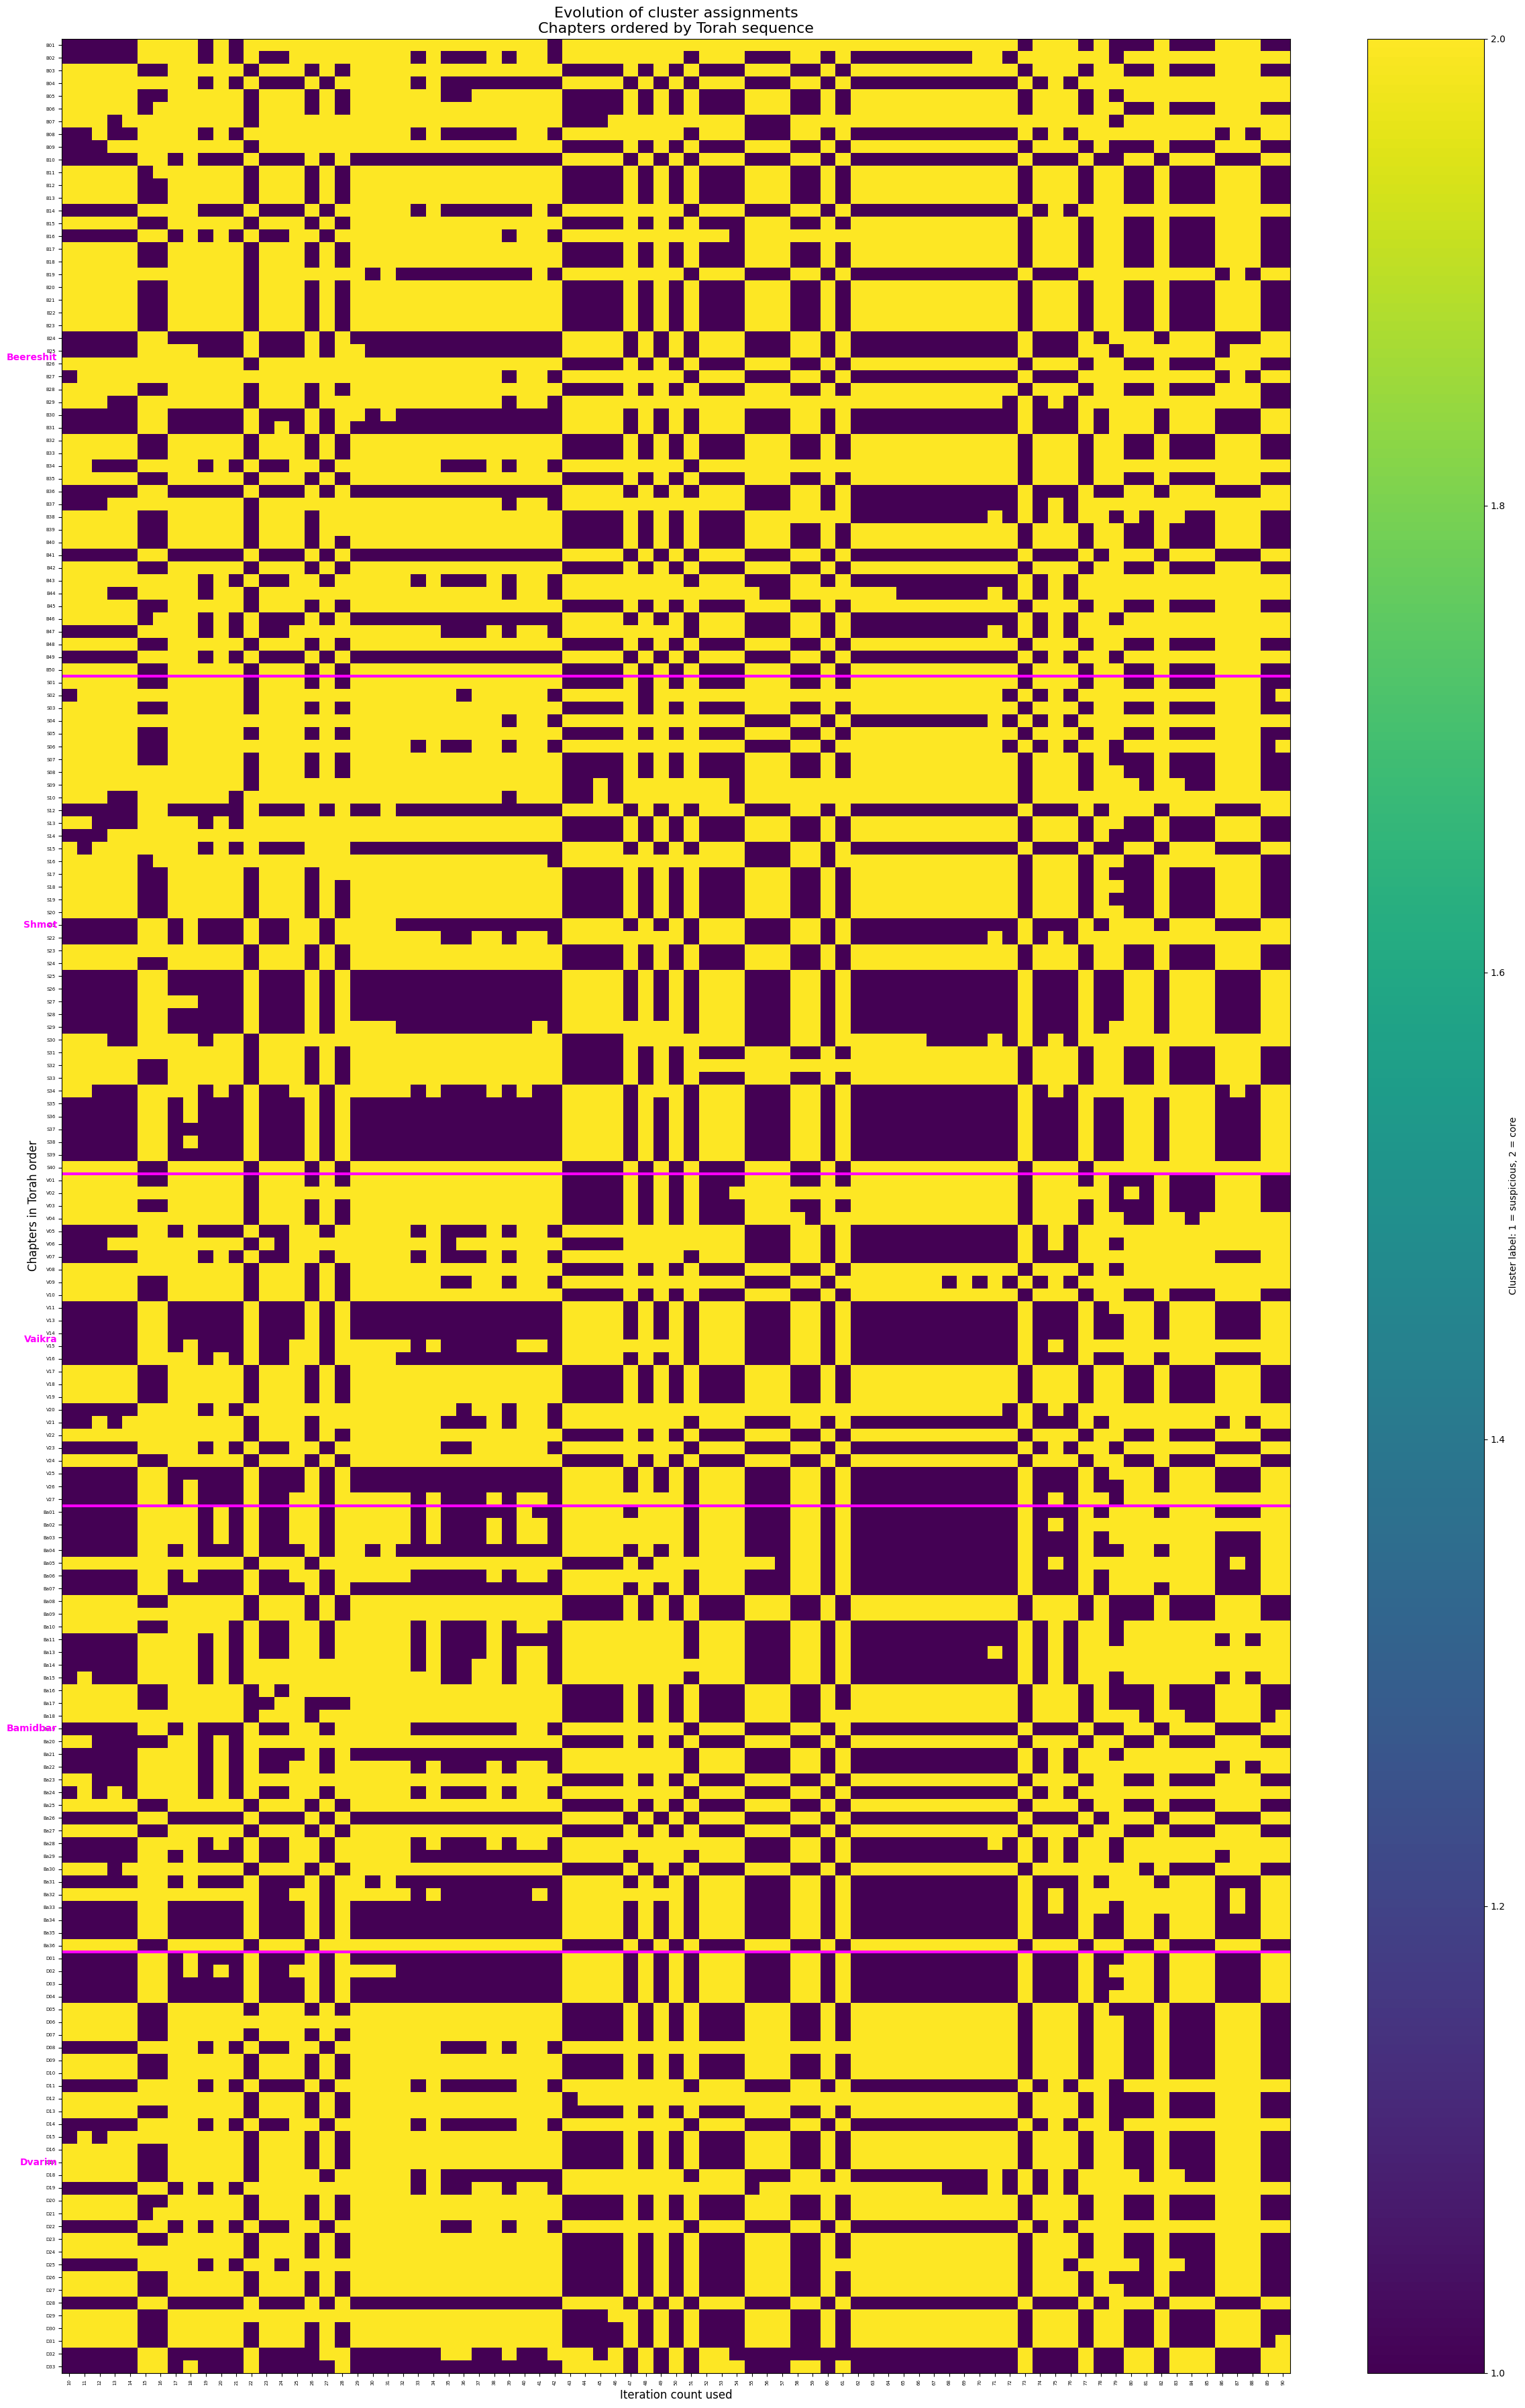

Evolution table in Torah order:


,chapter,book,chapter_number,average_evolution_label,evolution_suspicious,negative_count,negative_ratio,mean_anomaly_score
0,Beereshit_CH1,Beereshit,1,1.777778,0,9,0.100000,0.111726
1,Beereshit_CH2,Beereshit,2,1.629630,0,10,0.111111,0.100651
2,Beereshit_CH3,Beereshit,3,1.679012,0,7,0.077778,0.122001
3,Beereshit_CH4,Beereshit,4,1.567901,0,13,0.144444,0.091281
4,Beereshit_CH5,Beereshit,5,1.728395,0,14,0.155556,0.104920
...,...,...,...,...,...,...,...,...
178,Dvarim_CH29,Dvarim,29,1.728395,0,3,0.033333,0.118191
179,Dvarim_CH30,Dvarim,30,1.679012,0,3,0.033333,0.140477
180,Dvarim_CH31,Dvarim,31,1.691358,0,8,0.088889,0.106757
181,Dvarim_CH32,Dvarim,32,1.308642,1,41,0.455556,-0.022753


In [ ]:
# ============================================================
# Cell 3: Tracks how cluster assignments evolve as more iterations are included, then plots the evolution in Torah-order chapter layout.
# Keep the original execution order: run prerequisite cells first so shared variables are available.
# ============================================================

if "X" not in globals():
    raise RuntimeError("X was not found. Run cell 1 first.")

if "chapter_names" not in globals():
    raise RuntimeError("chapter_names was not found. Run cell 1 first.")

if "analysis_df" not in globals():
    raise RuntimeError("analysis_df was not found. Run cell 1 first.")

if "cluster_score_vectors" not in globals():
    raise RuntimeError("cluster_score_vectors was not found. Run cell 1 first.")

if "START_EVOLUTION_ITERATION" not in globals():
    raise RuntimeError("START_EVOLUTION_ITERATION was not found. Run cell 1 first.")

if "RANDOM_STATE" not in globals():
    raise RuntimeError("RANDOM_STATE was not found. Run cell 1 first.")

if "n_iterations" not in globals():
    n_iterations = X.shape[1]

if "EVOLUTION_FIGSIZE" not in globals():
    EVOLUTION_FIGSIZE = (24, 36)

if "EVOLUTION_AXIS_LABEL_FONT_SIZE" not in globals():
    EVOLUTION_AXIS_LABEL_FONT_SIZE = 5

if "SHOW_NAMES_ON_GRAPHS" not in globals():
    SHOW_NAMES_ON_GRAPHS = True


import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


TORAH_BOOK_ORDER = [
    "Beereshit",
    "Shmot",
    "Vaikra",
    "Bamidbar",
    "Dvarim"
]

BOOK_ORDER_MAP = {
    book_name: index
    for index, book_name in enumerate(TORAH_BOOK_ORDER)
}


def extract_chapter_number(chapter_name):
    """Helper function used by this cell."""

    chapter_name = str(chapter_name)

    match = re.search(r"_CH0*(\d+)", chapter_name)

    if match:
        return int(match.group(1))

    match = re.search(r"(\d+)", chapter_name)

    if match:
        return int(match.group(1))

    return 10**9


def short_chapter_label(chapter_name):
    """Helper function used by this cell."""

    chapter_name = str(chapter_name)

    if "_CH" in chapter_name:
        book_name, chapter_part = chapter_name.split("_CH", 1)

        chapter_digits = re.sub(r"\D", "", chapter_part)
        chapter_num = int(chapter_digits) if chapter_digits else 0

        short_book_map = {
            "Beereshit": "B",
            "Shmot": "S",
            "Vaikra": "V",
            "Bamidbar": "Ba",
            "Dvarim": "D"
        }

        short_book = short_book_map.get(book_name, book_name[:2])

        return f"{short_book}{chapter_num:02d}"

    return chapter_name[:10]


if START_EVOLUTION_ITERATION < 2:
    raise ValueError("START_EVOLUTION_ITERATION must be at least 2.")

if START_EVOLUTION_ITERATION > n_iterations:
    raise ValueError(
        f"START_EVOLUTION_ITERATION is larger than the total number of iterations: {n_iterations}"
    )


evolution_iterations = list(range(START_EVOLUTION_ITERATION, n_iterations + 1))
evolution_labels = []

for t in evolution_iterations:

    X_t = X[:, :t]

    labels_t, _, _ = cluster_score_vectors(
        X_t,
        random_state=RANDOM_STATE + t
    )

    evolution_labels.append(labels_t)

evolution_matrix = np.column_stack(evolution_labels)


average_evolution_label = evolution_matrix.mean(axis=1)

evolution_suspicious = (average_evolution_label < 1.5).astype(int)

analysis_df["average_evolution_label"] = average_evolution_label
analysis_df["evolution_suspicious"] = evolution_suspicious


print("\nEvolution of cluster assignments summary:")
print("Number of suspicious chapters by evolution:", int(evolution_suspicious.sum()))
print("Number of core chapters by evolution:", int(len(evolution_suspicious) - evolution_suspicious.sum()))

print("\nSuspicious chapters by evolution:")
display(
    analysis_df[analysis_df["evolution_suspicious"] == 1]
    .sort_values("average_evolution_label")
    [["chapter", "book", "average_evolution_label", "negative_count", "negative_ratio", "mean_anomaly_score"]]
)


torah_order_df = analysis_df.copy()

torah_order_df["original_index"] = torah_order_df.index
torah_order_df["book_order"] = torah_order_df["book"].map(BOOK_ORDER_MAP)
torah_order_df["chapter_number"] = torah_order_df["chapter"].apply(extract_chapter_number)

torah_order_df["book_order"] = torah_order_df["book_order"].fillna(10**9)

torah_order_df = (
    torah_order_df
    .sort_values(["book_order", "chapter_number", "chapter"])
    .reset_index(drop=True)
)

torah_order_indices = torah_order_df["original_index"].to_numpy()

evolution_sorted_by_torah = evolution_matrix[torah_order_indices, :]

chapters_sorted_by_torah = torah_order_df["chapter"].to_numpy()
short_chapters_sorted_by_torah = [
    short_chapter_label(chapter)
    for chapter in chapters_sorted_by_torah
]


book_sizes = (
    torah_order_df
    .groupby("book", sort=False)
    .size()
)

book_boundaries = []
book_centers = []
book_names_for_plot = []

start_index = 0

for book_name, size in book_sizes.items():

    end_index = start_index + size
    center = start_index + (size - 1) / 2

    book_centers.append(center)
    book_names_for_plot.append(book_name)

    book_boundaries.append(end_index - 0.5)

    start_index = end_index


plt.figure(figsize=EVOLUTION_FIGSIZE)

plt.imshow(
    evolution_sorted_by_torah,
    aspect="auto",
    interpolation="nearest"
)

plt.title(
    "Evolution of cluster assignments\nChapters ordered by Torah sequence",
    fontsize=16
)

plt.xlabel("Iteration count used", fontsize=12)
plt.ylabel("Chapters in Torah order", fontsize=12)

plt.colorbar(label="Cluster label: 1 = suspicious, 2 = core")


x_ticks = np.arange(len(evolution_iterations))

plt.xticks(
    x_ticks,
    evolution_iterations,
    rotation=90,
    fontsize=EVOLUTION_AXIS_LABEL_FONT_SIZE
)


if SHOW_NAMES_ON_GRAPHS:
    plt.yticks(
        np.arange(len(short_chapters_sorted_by_torah)),
        short_chapters_sorted_by_torah,
        fontsize=EVOLUTION_AXIS_LABEL_FONT_SIZE
    )


BOOK_SEPARATOR_COLOR = "magenta"
BOOK_SEPARATOR_LINEWIDTH = 3

for boundary in book_boundaries[:-1]:

    plt.axhline(
        y=boundary,
        color=BOOK_SEPARATOR_COLOR,
        linewidth=BOOK_SEPARATOR_LINEWIDTH
    )


for center, book_name in zip(book_centers, book_names_for_plot):

    plt.text(
        x=-0.8,
        y=center,
        s=book_name,
        ha="right",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=BOOK_SEPARATOR_COLOR
    )


plt.tight_layout()
plt.show()


print("Evolution table in Torah order:")
display(
    torah_order_df[
        [
            "chapter",
            "book",
            "chapter_number",
            "average_evolution_label",
            "evolution_suspicious",
            "negative_count",
            "negative_ratio",
            "mean_anomaly_score"
        ]
    ].reset_index(drop=True)
)


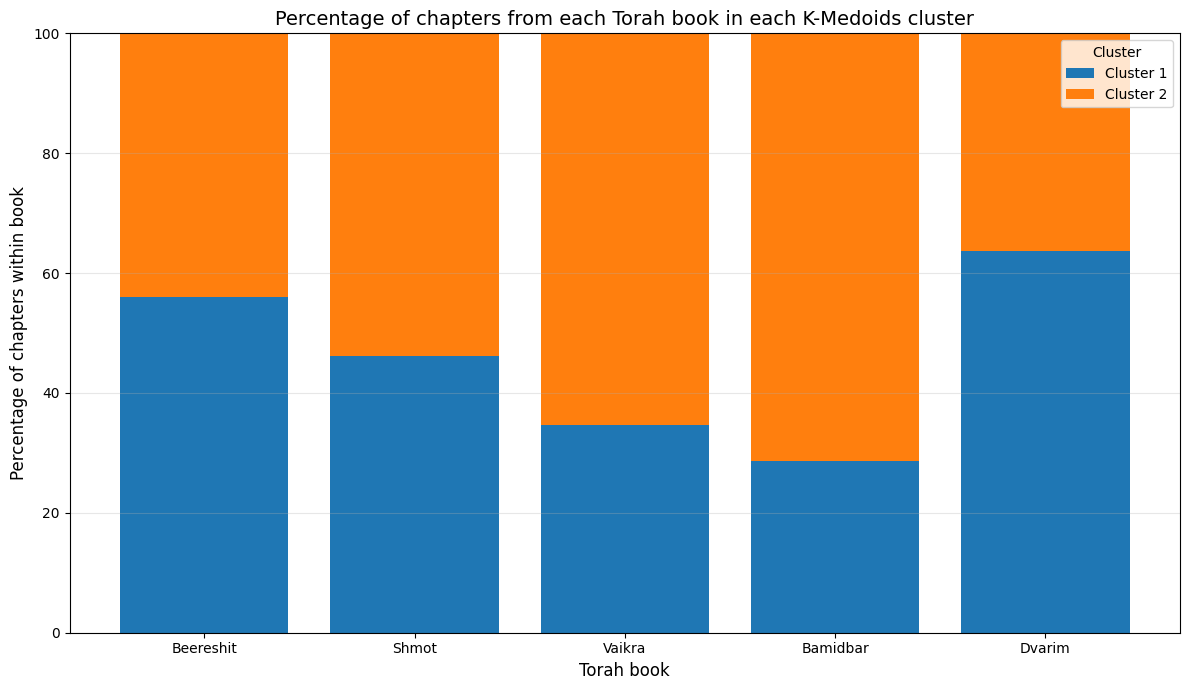

Percentage of chapters from each book in each cluster:


straight_label,1,2
book,,
Beereshit,56.00,44.00
Shmot,46.15,53.85
Vaikra,34.62,65.38
Bamidbar,28.57,71.43
Dvarim,63.64,36.36


Chapter counts from each book in each cluster:


straight_label,1,2
book,,
Beereshit,28,22
Shmot,18,21
Vaikra,9,17
Bamidbar,10,25
Dvarim,21,12


In [ ]:
# ============================================================
# Cell 4: Shows what percentage of each Torah book belongs to each cluster using a stacked bar chart.
# Keep the original execution order: run prerequisite cells first so shared variables are available.
# ============================================================

if "analysis_df" not in globals():
    raise RuntimeError("analysis_df was not found. Run cell 1 first.")

if "straight_label" not in analysis_df.columns:
    raise RuntimeError("The straight_label column was not found in analysis_df. Run cell 1 first.")


TORAH_BOOK_ORDER = [
    "Beereshit",
    "Shmot",
    "Vaikra",
    "Bamidbar",
    "Dvarim"
]


cluster_counts_by_book = (
    analysis_df
    .groupby(["book", "straight_label"])
    .size()
    .unstack(fill_value=0)
)


existing_books_in_order = [
    book for book in TORAH_BOOK_ORDER
    if book in cluster_counts_by_book.index
]

cluster_counts_by_book = cluster_counts_by_book.loc[existing_books_in_order]


cluster_percent_by_book = (
    cluster_counts_by_book
    .div(cluster_counts_by_book.sum(axis=1), axis=0)
    * 100
)


plt.figure(figsize=(12, 7))

bottom = np.zeros(len(cluster_percent_by_book))

for cluster_label in sorted(cluster_percent_by_book.columns):

    values = cluster_percent_by_book[cluster_label].values

    plt.bar(
        cluster_percent_by_book.index,
        values,
        bottom=bottom,
        label=f"Cluster {cluster_label}"
    )

    bottom += values


plt.title(
    "Percentage of chapters from each Torah book in each K-Medoids cluster",
    fontsize=14
)

plt.xlabel("Torah book", fontsize=12)
plt.ylabel("Percentage of chapters within book", fontsize=12)

plt.ylim(0, 100)
plt.legend(title="Cluster")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


print("Percentage of chapters from each book in each cluster:")
display(cluster_percent_by_book.round(2))


print("Chapter counts from each book in each cluster:")
display(cluster_counts_by_book)


/tmp/ipykernel_9403/1469832521.py:148: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


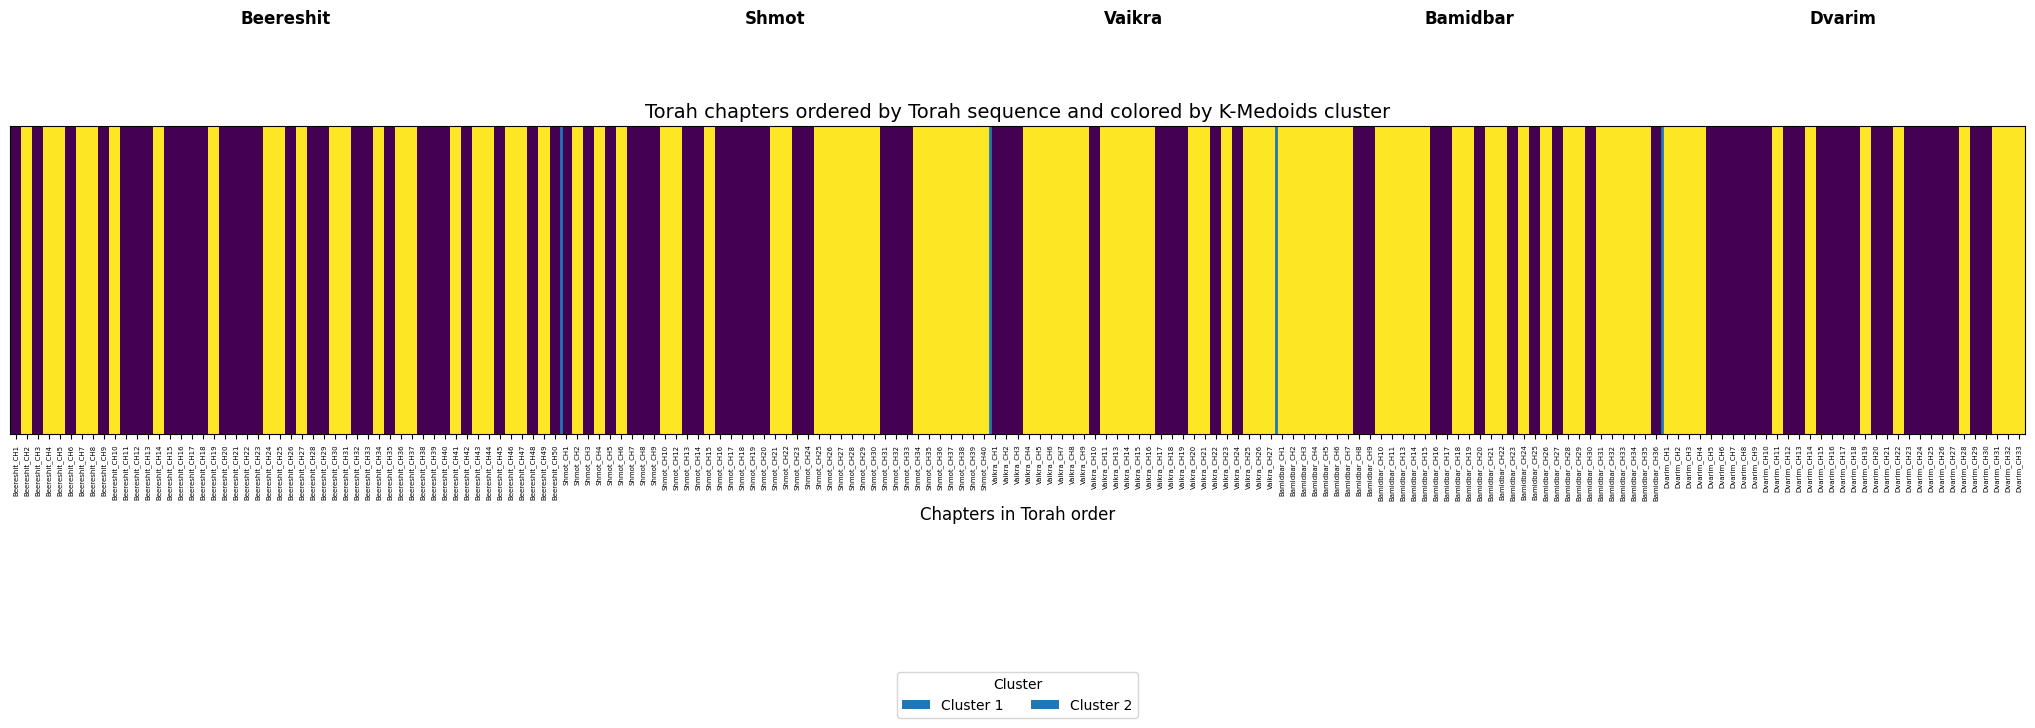

,chapter,book,chapter_number,straight_label,negative_count,negative_ratio,mean_anomaly_score
0,Beereshit_CH1,Beereshit,1,1,9,0.100000,0.111726
1,Beereshit_CH2,Beereshit,2,2,10,0.111111,0.100651
2,Beereshit_CH3,Beereshit,3,1,7,0.077778,0.122001
3,Beereshit_CH4,Beereshit,4,2,13,0.144444,0.091281
4,Beereshit_CH5,Beereshit,5,2,14,0.155556,0.104920
...,...,...,...,...,...,...,...
178,Dvarim_CH29,Dvarim,29,1,3,0.033333,0.118191
179,Dvarim_CH30,Dvarim,30,1,3,0.033333,0.140477
180,Dvarim_CH31,Dvarim,31,2,8,0.088889,0.106757
181,Dvarim_CH32,Dvarim,32,2,41,0.455556,-0.022753


In [ ]:
# ============================================================
# Cell 5: Displays all chapters in Torah order as a one-row cluster strip with book boundaries.
# Keep the original execution order: run prerequisite cells first so shared variables are available.
# ============================================================

if "analysis_df" not in globals():
    raise RuntimeError("analysis_df was not found. Run cell 1 first.")

if "straight_label" not in analysis_df.columns:
    raise RuntimeError("The straight_label column was not found in analysis_df. Run cell 1 first.")


TORAH_BOOK_ORDER = [
    "Beereshit",
    "Shmot",
    "Vaikra",
    "Bamidbar",
    "Dvarim"
]

BOOK_ORDER_MAP = {
    book_name: index
    for index, book_name in enumerate(TORAH_BOOK_ORDER)
}


def extract_chapter_number(chapter_name):
    chapter_name = str(chapter_name)

    match = re.search(r"_CH0*(\d+)", chapter_name)

    if match:
        return int(match.group(1))

    match = re.search(r"(\d+)", chapter_name)

    if match:
        return int(match.group(1))

    return 10**9


torah_order_df = analysis_df.copy()

torah_order_df["book_order"] = torah_order_df["book"].map(BOOK_ORDER_MAP)
torah_order_df["chapter_number"] = torah_order_df["chapter"].apply(extract_chapter_number)

torah_order_df["book_order"] = torah_order_df["book_order"].fillna(10**9)

torah_order_df = (
    torah_order_df
    .sort_values(["book_order", "chapter_number", "chapter"])
    .reset_index(drop=True)
)


cluster_strip = torah_order_df["straight_label"].to_numpy().reshape(1, -1)
chapter_labels_ordered = torah_order_df["chapter"].to_numpy()


book_sizes = (
    torah_order_df
    .groupby("book", sort=False)
    .size()
)

book_boundaries = []
book_centers = []
book_names_for_plot = []

start_index = 0

for book_name, size in book_sizes.items():

    end_index = start_index + size

    center = start_index + (size - 1) / 2

    book_centers.append(center)
    book_names_for_plot.append(book_name)

    book_boundaries.append(end_index - 0.5)

    start_index = end_index


plt.figure(figsize=(26, 4))

plt.imshow(
    cluster_strip,
    aspect="auto",
    interpolation="nearest"
)

plt.title(
    "Torah chapters ordered by Torah sequence and colored by K-Medoids cluster",
    fontsize=14
)

plt.xlabel("Chapters in Torah order", fontsize=12)
plt.yticks([])


plt.xticks(
    ticks=np.arange(len(chapter_labels_ordered)),
    labels=chapter_labels_ordered,
    rotation=90,
    fontsize=5
)


for boundary in book_boundaries[:-1]:
    plt.axvline(
        boundary,
        linewidth=2
    )


for center, book_name in zip(book_centers, book_names_for_plot):
    plt.text(
        center,
        -0.85,
        book_name,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold"
    )


from matplotlib.patches import Patch

unique_clusters = sorted(torah_order_df["straight_label"].unique())

legend_handles = [
    Patch(label=f"Cluster {cluster_label}")
    for cluster_label in unique_clusters
]

plt.legend(
    handles=legend_handles,
    title="Cluster",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.75),
    ncol=len(unique_clusters)
)

plt.tight_layout()
plt.show()


display(
    torah_order_df[
        ["chapter", "book", "chapter_number", "straight_label", "negative_count", "negative_ratio", "mean_anomaly_score"]
    ]
)


Note: adjustText is not installed. For automatic label adjustment, run:
!pip install adjustText


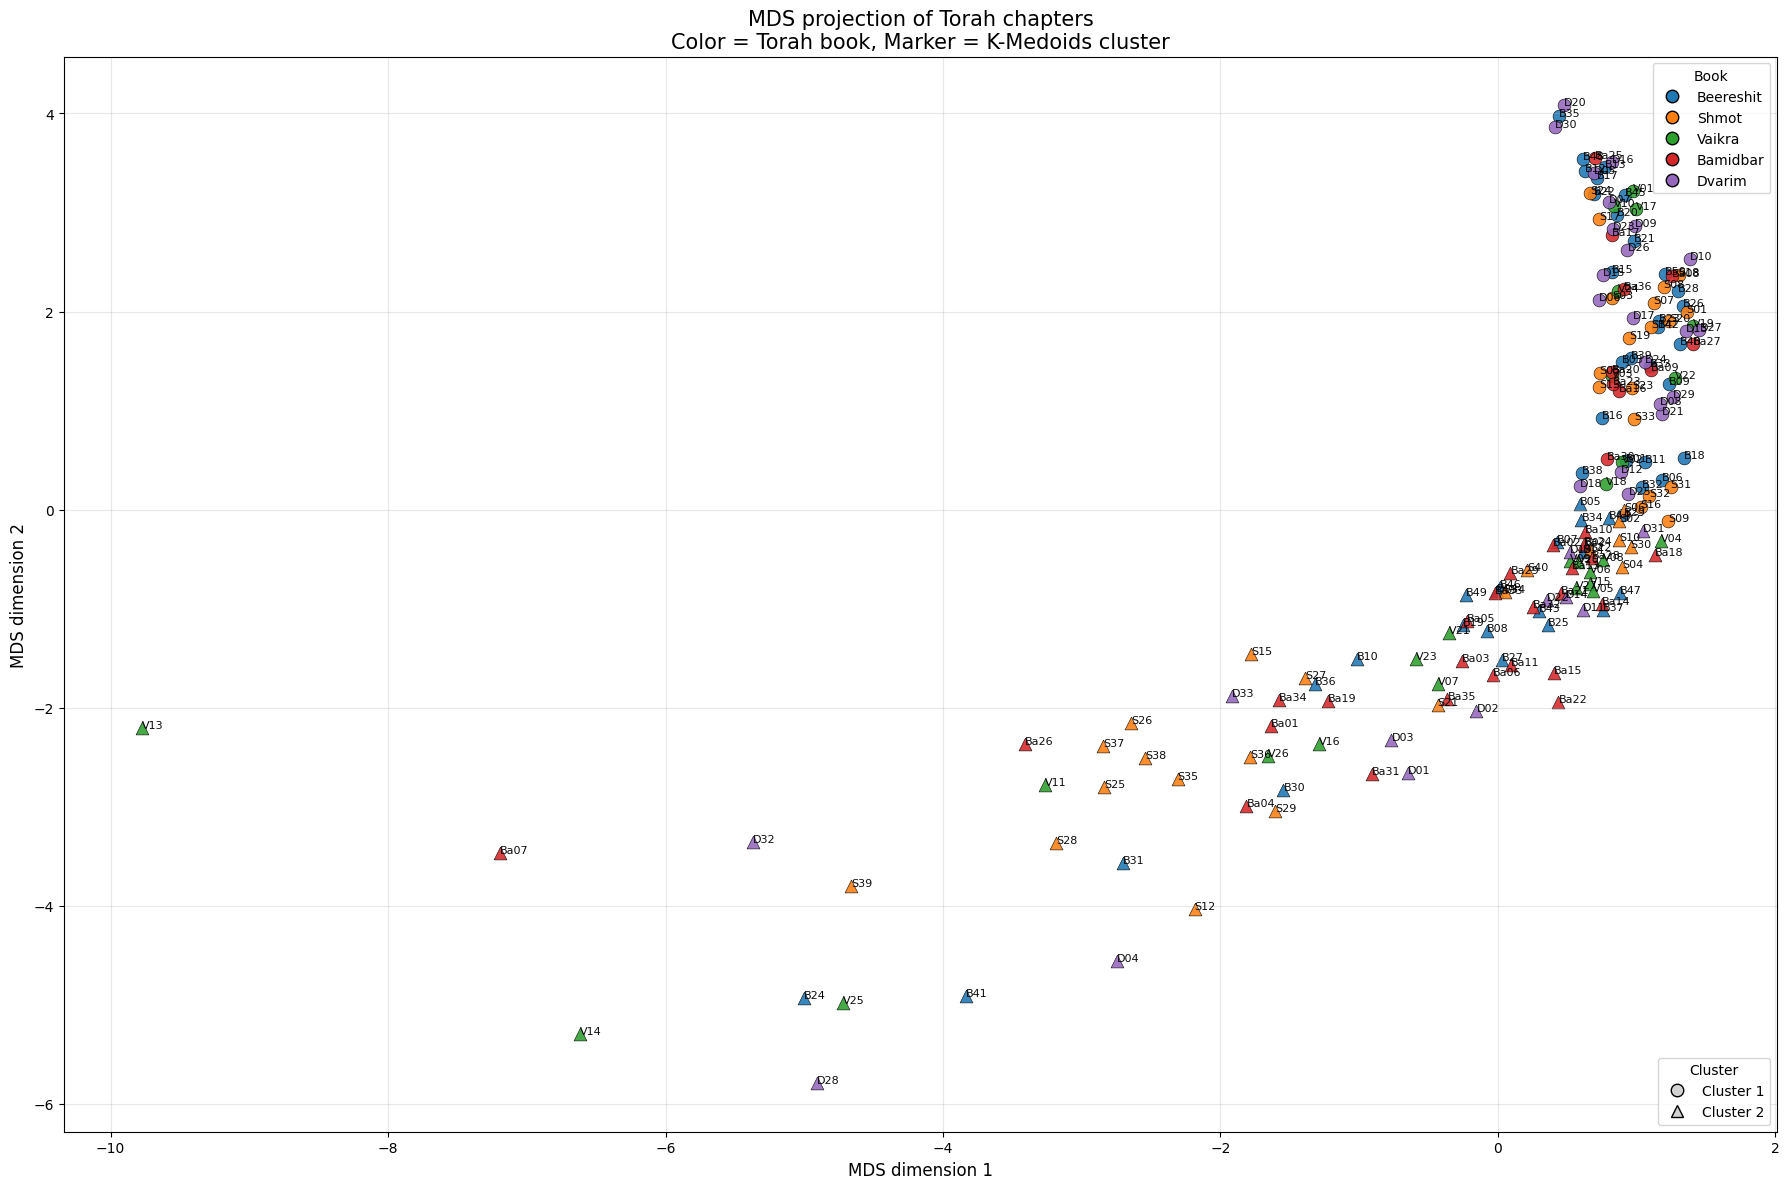

Full MDS table:


,chapter,book,straight_label,mds_x,mds_y,short_label
0,Bamidbar_CH1,Bamidbar,2,-1.637764,-2.184884,Ba01
1,Bamidbar_CH10,Bamidbar,2,0.629829,-0.224012,Ba10
2,Bamidbar_CH11,Bamidbar,2,0.094159,-1.572553,Ba11
3,Bamidbar_CH13,Bamidbar,2,0.533578,-0.590437,Ba13
4,Bamidbar_CH14,Bamidbar,2,0.749683,-0.958428,Ba14
...,...,...,...,...,...,...
178,Vaikra_CH5,Vaikra,2,0.687753,-0.823415,V05
179,Vaikra_CH6,Vaikra,2,0.664165,-0.633519,V06
180,Vaikra_CH7,Vaikra,2,-0.431586,-1.765058,V07
181,Vaikra_CH8,Vaikra,2,0.756760,-0.504595,V08



Densest area detected on the X axis:
X from -1.390 to 1.418
Number of points in this area: 153 out of 183
Percentage of points: 83.61%
Search-window width: 25.0% of the full X range


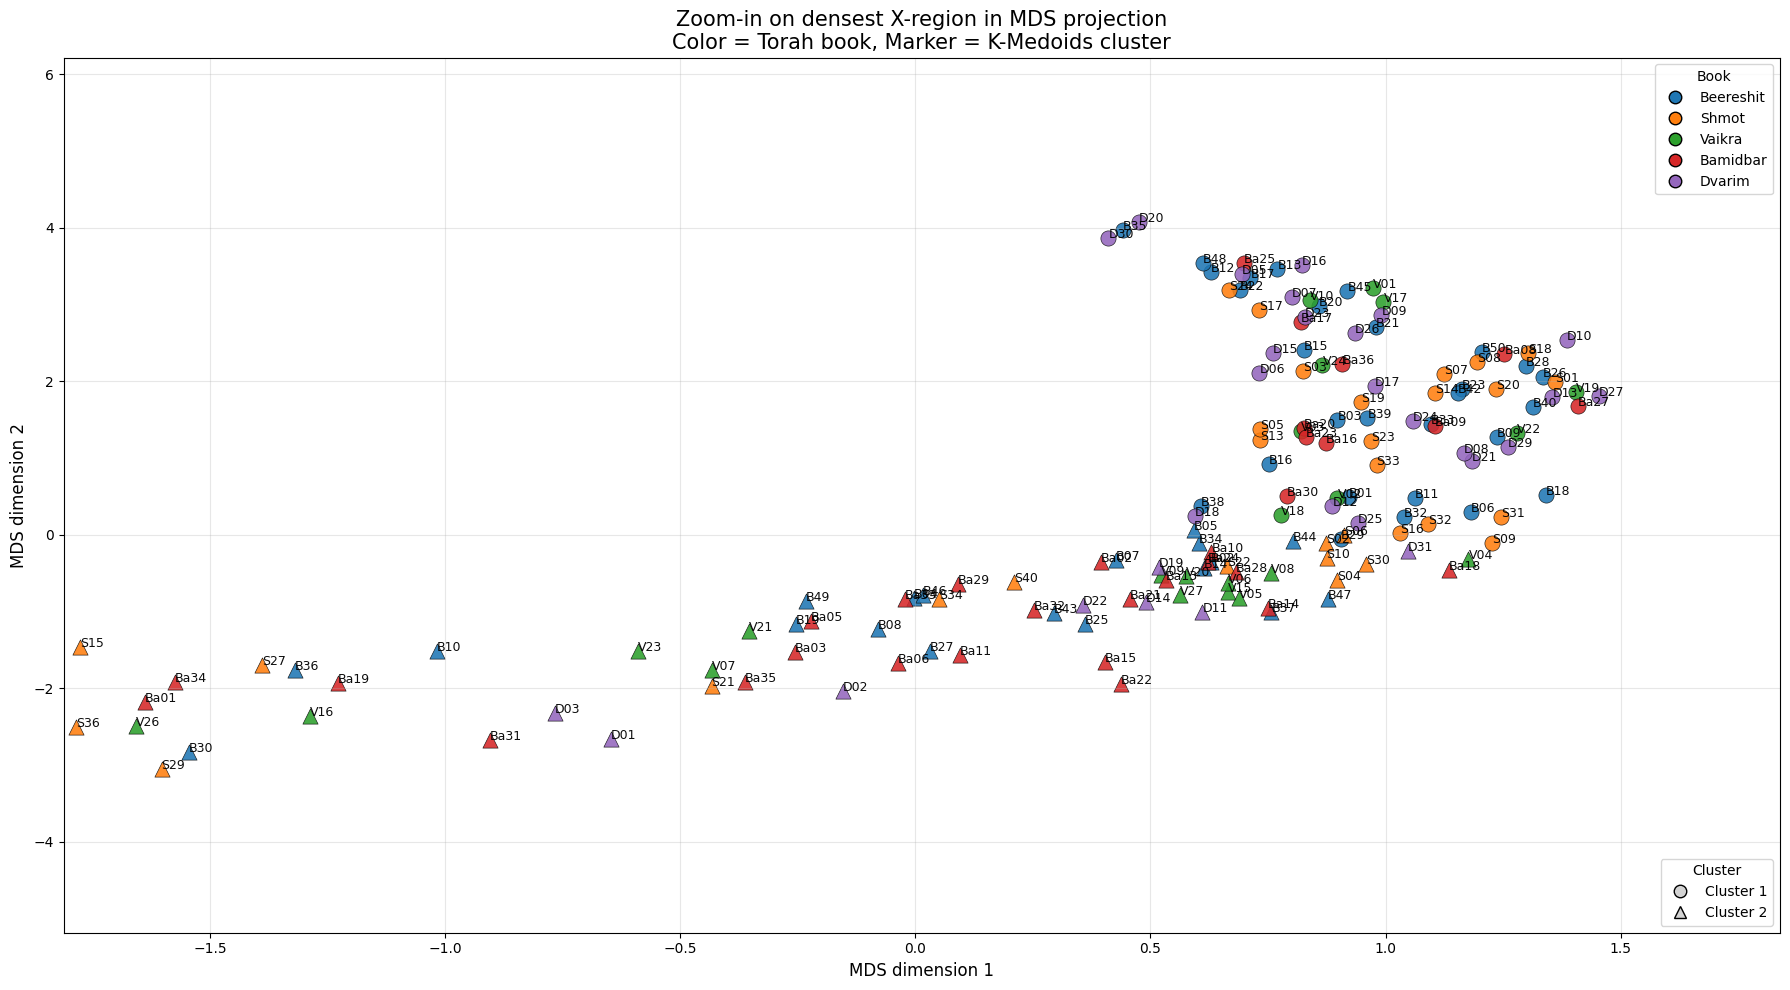

Chapters in the dense area:


,chapter,book,straight_label,mds_x,mds_y,short_label
146,Shmot_CH36,Shmot,2,-1.783734,-2.503472,S36
123,Shmot_CH15,Shmot,2,-1.776904,-1.459975,S15
174,Vaikra_CH26,Vaikra,2,-1.656992,-2.486820,V26
0,Bamidbar_CH1,Bamidbar,2,-1.637764,-2.184884,Ba01
138,Shmot_CH29,Shmot,2,-1.602648,-3.048545,S29
...,...,...,...,...,...,...
118,Shmot_CH1,Shmot,1,1.361074,1.992524,S01
86,Dvarim_CH10,Dvarim,1,1.385303,2.535454,D10
166,Vaikra_CH19,Vaikra,1,1.405503,1.856213,V19
18,Bamidbar_CH27,Bamidbar,1,1.409293,1.676326,Ba27


In [ ]:
# ============================================================
# Cell 6: Runs MDS on the chapter distance matrix, draws a full scatter plot, and adds a zoomed view of the densest X-axis region.
# Keep the original execution order: run prerequisite cells first so shared variables are available.
# ============================================================

if "analysis_df" not in globals():
    raise RuntimeError("analysis_df was not found. Run cell 1 first.")

if "full_distance_matrix" not in globals():
    raise RuntimeError("full_distance_matrix was not found. Run cell 1 first.")

if "straight_labels" not in globals():
    raise RuntimeError("straight_labels was not found. Run cell 1 first.")

required_columns = ["chapter", "book", "straight_label"]

for col in required_columns:
    if col not in analysis_df.columns:
        raise RuntimeError(f"Column was not found {col} in analysis_df.")


import re
import numpy as np
import matplotlib.pyplot as plt

from sklearn.manifold import MDS
from matplotlib.lines import Line2D


try:
    from adjustText import adjust_text
    ADJUST_TEXT_AVAILABLE = True
except ImportError:
    ADJUST_TEXT_AVAILABLE = False
    print("Note: adjustText is not installed. For automatic label adjustment, run:")
    print("!pip install adjustText")


MDS_RANDOM_STATE = 42

MAIN_FIGSIZE = (18, 12)
ZOOM_FIGSIZE = (18, 10)

SHOW_ALL_POINT_LABELS = True

ADJUST_LABELS_IN_MAIN_GRAPH = False

ADJUST_LABELS_IN_ZOOM_GRAPH = True

DENSE_WINDOW_PERCENT = 0.25

DENSE_X_PADDING_PERCENT = 0.15
DENSE_Y_PADDING_PERCENT = 0.30

MAIN_POINT_SIZE = 85
ZOOM_POINT_SIZE = 120

MAIN_LABEL_FONT_SIZE = 8
ZOOM_LABEL_FONT_SIZE = 9


CLUSTER_MARKERS = {
    1: "o",   # suspicious / smaller cluster
    2: "^"    # core / larger cluster
}

BOOK_COLORS = {
    "Beereshit": "C0",
    "Shmot": "C1",
    "Vaikra": "C2",
    "Bamidbar": "C3",
    "Dvarim": "C4"
}

TORAH_BOOK_ORDER = [
    "Beereshit",
    "Shmot",
    "Vaikra",
    "Bamidbar",
    "Dvarim"
]


def short_chapter_label(chapter_name: str) -> str:
    """Helper function used by this cell."""

    chapter_name = str(chapter_name)

    if "_CH" in chapter_name:
        book_name, chapter_part = chapter_name.split("_CH", 1)

        chapter_digits = re.sub(r"\D", "", chapter_part)
        chapter_num = int(chapter_digits) if chapter_digits else 0

        short_book_map = {
            "Beereshit": "B",
            "Shmot": "S",
            "Vaikra": "V",
            "Bamidbar": "Ba",
            "Dvarim": "D"
        }

        short_book = short_book_map.get(book_name, book_name[:2])

        return f"{short_book}{chapter_num:02d}"

    return chapter_name[:10]


def find_densest_x_window(plot_df, x_col="mds_x", window_percent=0.25):
    """Helper function used by this cell."""

    x_values = np.sort(plot_df[x_col].to_numpy())

    x_min = x_values.min()
    x_max = x_values.max()
    x_range = x_max - x_min

    window_width = x_range * window_percent

    if window_width <= 0:
        return x_min, x_max, len(x_values)

    best_start = x_min
    best_end = x_min + window_width
    best_count = 0

    for start in x_values:
        end = start + window_width

        count = np.sum((x_values >= start) & (x_values <= end))

        if count > best_count:
            best_count = count
            best_start = start
            best_end = end

    return best_start, best_end, best_count


def draw_mds_scatter(
    df,
    title,
    figsize,
    point_size,
    label_font_size,
    adjust_labels=False,
    xlim=None,
    ylim=None
):
    """Helper function used by this cell."""

    plt.figure(figsize=figsize)

    texts = []

    for book_name in book_values:

        book_color = BOOK_COLORS.get(book_name, "gray")

        for cluster_label in cluster_values:

            marker_style = CLUSTER_MARKERS.get(cluster_label, "o")

            subset = df[
                (df["book"] == book_name) &
                (df["straight_label"] == cluster_label)
            ]

            if len(subset) == 0:
                continue

            plt.scatter(
                subset["mds_x"],
                subset["mds_y"],
                marker=marker_style,
                c=book_color,
                s=point_size,
                alpha=0.88,
                edgecolors="black",
                linewidths=0.45
            )


    if SHOW_ALL_POINT_LABELS:

        for _, row in df.iterrows():

            text = plt.text(
                row["mds_x"],
                row["mds_y"],
                row["short_label"],
                fontsize=label_font_size,
                alpha=0.95
            )

            texts.append(text)

        if adjust_labels and ADJUST_TEXT_AVAILABLE:
            adjust_text(
                texts,
                expand_points=(1.4, 1.7),
                expand_text=(1.3, 1.6),
                force_text=(0.4, 0.7),
                force_points=(0.3, 0.5),
                arrowprops=dict(
                    arrowstyle="-",
                    lw=0.4,
                    alpha=0.5
                )
            )


    if xlim is not None:
        plt.xlim(xlim[0], xlim[1])

    if ylim is not None:
        plt.ylim(ylim[0], ylim[1])


    plt.title(title, fontsize=15)
    plt.xlabel("MDS dimension 1", fontsize=12)
    plt.ylabel("MDS dimension 2", fontsize=12)
    plt.grid(alpha=0.3)


    legend_books = plt.legend(
        handles=book_legend_handles,
        title="Book",
        loc="upper right"
    )

    plt.gca().add_artist(legend_books)

    plt.legend(
        handles=cluster_legend_handles,
        title="Cluster",
        loc="lower right"
    )

    plt.tight_layout()
    plt.show()


mds = MDS(
    n_components=2,
    dissimilarity="precomputed",
    random_state=MDS_RANDOM_STATE
)

mds_coordinates = mds.fit_transform(full_distance_matrix)


plot_df = analysis_df.copy()

plot_df["mds_x"] = mds_coordinates[:, 0]
plot_df["mds_y"] = mds_coordinates[:, 1]
plot_df["short_label"] = plot_df["chapter"].apply(short_chapter_label)


book_values = [
    book for book in TORAH_BOOK_ORDER
    if book in plot_df["book"].unique()
]

cluster_values = sorted(plot_df["straight_label"].unique())


book_legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markersize=9,
        label=book_name,
        markerfacecolor=BOOK_COLORS.get(book_name, "gray"),
        markeredgecolor="black",
        color="black"
    )
    for book_name in book_values
]

cluster_legend_handles = [
    Line2D(
        [0], [0],
        marker=CLUSTER_MARKERS.get(cluster_label, "o"),
        linestyle="",
        markersize=9,
        label=f"Cluster {cluster_label}",
        markerfacecolor="lightgray",
        markeredgecolor="black",
        color="black"
    )
    for cluster_label in cluster_values
]


draw_mds_scatter(
    df=plot_df,
    title=(
        "MDS projection of Torah chapters\n"
        "Color = Torah book, Marker = K-Medoids cluster"
    ),
    figsize=MAIN_FIGSIZE,
    point_size=MAIN_POINT_SIZE,
    label_font_size=MAIN_LABEL_FONT_SIZE,
    adjust_labels=ADJUST_LABELS_IN_MAIN_GRAPH
)


print("Full MDS table:")
display(
    plot_df[
        ["chapter", "book", "straight_label", "mds_x", "mds_y", "short_label"]
    ].sort_values(["book", "chapter"])
)


dense_x_start, dense_x_end, dense_count = find_densest_x_window(
    plot_df,
    x_col="mds_x",
    window_percent=DENSE_WINDOW_PERCENT
)

x_width = dense_x_end - dense_x_start
x_padding = x_width * DENSE_X_PADDING_PERCENT

zoom_x_min = dense_x_start - x_padding
zoom_x_max = dense_x_end + x_padding

zoom_df = plot_df[
    (plot_df["mds_x"] >= zoom_x_min) &
    (plot_df["mds_x"] <= zoom_x_max)
].copy()


if len(zoom_df) > 0:

    y_min = zoom_df["mds_y"].min()
    y_max = zoom_df["mds_y"].max()
    y_range = y_max - y_min

    if y_range == 0:
        y_range = 1

    y_padding = y_range * DENSE_Y_PADDING_PERCENT

    zoom_y_min = y_min - y_padding
    zoom_y_max = y_max + y_padding

else:
    raise RuntimeError("No points were found in the zoom area. Try increasing DENSE_WINDOW_PERCENT.")


print("\nDensest area detected on the X axis:")
print(f"X from {dense_x_start:.3f} to {dense_x_end:.3f}")
print(f"Number of points in this area: {dense_count} out of {len(plot_df)}")
print(f"Percentage of points: {100 * dense_count / len(plot_df):.2f}%")
print(f"Search-window width: {DENSE_WINDOW_PERCENT * 100:.1f}% of the full X range")


draw_mds_scatter(
    df=zoom_df,
    title=(
        "Zoom-in on densest X-region in MDS projection\n"
        "Color = Torah book, Marker = K-Medoids cluster"
    ),
    figsize=ZOOM_FIGSIZE,
    point_size=ZOOM_POINT_SIZE,
    label_font_size=ZOOM_LABEL_FONT_SIZE,
    adjust_labels=ADJUST_LABELS_IN_ZOOM_GRAPH,
    xlim=(zoom_x_min, zoom_x_max),
    ylim=(zoom_y_min, zoom_y_max)
)


print("Chapters in the dense area:")
display(
    zoom_df[
        ["chapter", "book", "straight_label", "mds_x", "mds_y", "short_label"]
    ].sort_values(["mds_x", "mds_y"])
)


Book-distance matrix using mean:


,Beereshit,Shmot,Vaikra,Bamidbar,Dvarim
Beereshit,2.7730,2.9071,3.2528,2.7136,3.0171
Shmot,2.9071,3.0102,3.3751,2.8779,3.2419
Vaikra,3.2528,3.3751,3.9833,3.2043,3.5948
Bamidbar,2.7136,2.8779,3.2043,2.7154,3.1107
Dvarim,3.0171,3.2419,3.5948,3.1107,3.4376


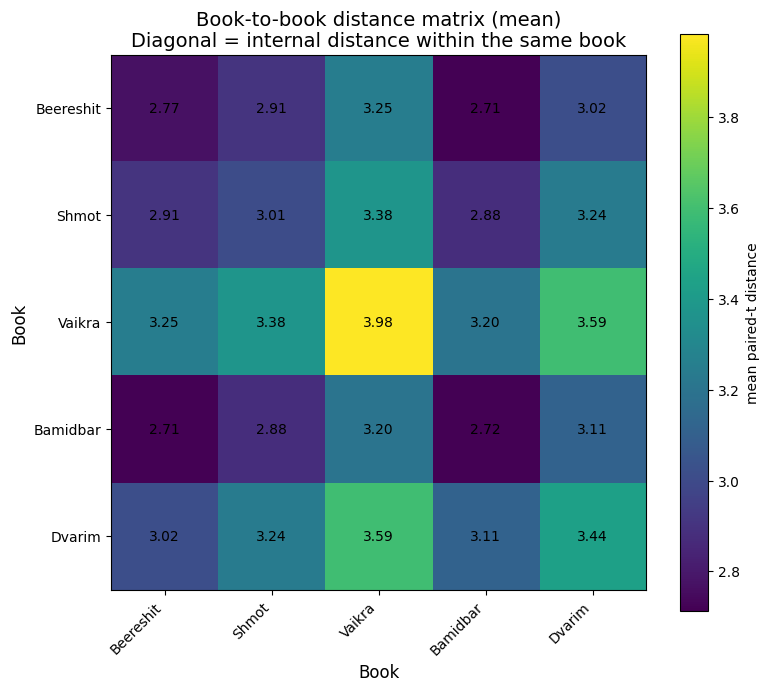

Brief interpretation:
The diagonal shows the internal distance between different chapters within the same book.
Off-diagonal cells show the distance between chapters from two different books.
A higher value means the book/chapter patterns differ more according to the paired-t distance matrix.


In [ ]:
# ============================================================
# Cell 7: Aggregates chapter-level distances into a book-level distance matrix and plots it as a heatmap.
# Keep the original execution order: run prerequisite cells first so shared variables are available.
# ============================================================

if "analysis_df" not in globals():
    raise RuntimeError("analysis_df was not found. Run cell 1 first.")

if "full_distance_matrix" not in globals():
    raise RuntimeError("full_distance_matrix was not found. Run cell 1 first.")

required_columns = ["chapter", "book"]

for col in required_columns:
    if col not in analysis_df.columns:
        raise RuntimeError(f"Column was not found {col} in analysis_df.")


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


TORAH_BOOK_ORDER = [
    "Beereshit",
    "Shmot",
    "Vaikra",
    "Bamidbar",
    "Dvarim"
]

BOOK_DISTANCE_AGGREGATION = "mean"

BOOK_DISTANCE_FIGSIZE = (8, 7)

SHOW_VALUES_ON_HEATMAP = True


def aggregate_distances(values, method="mean"):
    """Helper function used by this cell."""

    values = np.asarray(values, dtype=float)

    values = values[~np.isnan(values)]

    if len(values) == 0:
        return np.nan

    if method == "mean":
        return np.mean(values)

    if method == "median":
        return np.median(values)

    raise ValueError("BOOK_DISTANCE_AGGREGATION must be 'mean' or 'median'.")


existing_books = [
    book for book in TORAH_BOOK_ORDER
    if book in analysis_df["book"].unique()
]

if len(existing_books) == 0:
    raise RuntimeError("No books from TORAH_BOOK_ORDER were found in analysis_df['book'].")


book_distance_matrix = pd.DataFrame(
    index=existing_books,
    columns=existing_books,
    dtype=float
)

book_indices = {
    book: analysis_df.index[analysis_df["book"] == book].to_numpy()
    for book in existing_books
}


for book_a in existing_books:

    indices_a = book_indices[book_a]

    for book_b in existing_books:

        indices_b = book_indices[book_b]

        distances_block = full_distance_matrix[np.ix_(indices_a, indices_b)]

        if book_a == book_b:
            if distances_block.shape[0] <= 1:
                values = np.array([])
            else:
                mask = ~np.eye(distances_block.shape[0], dtype=bool)
                values = distances_block[mask]
        else:
            values = distances_block.flatten()

        book_distance_matrix.loc[book_a, book_b] = aggregate_distances(
            values,
            method=BOOK_DISTANCE_AGGREGATION
        )


print(f"Book-distance matrix using {BOOK_DISTANCE_AGGREGATION}:")
display(book_distance_matrix.round(4))


plt.figure(figsize=BOOK_DISTANCE_FIGSIZE)

plt.imshow(
    book_distance_matrix.values,
    aspect="equal"
)

plt.title(
    f"Book-to-book distance matrix ({BOOK_DISTANCE_AGGREGATION})\n"
    "Diagonal = internal distance within the same book",
    fontsize=14
)

plt.xlabel("Book", fontsize=12)
plt.ylabel("Book", fontsize=12)

plt.xticks(
    ticks=np.arange(len(existing_books)),
    labels=existing_books,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(existing_books)),
    labels=existing_books
)

plt.colorbar(label=f"{BOOK_DISTANCE_AGGREGATION} paired-t distance")


if SHOW_VALUES_ON_HEATMAP:

    for i in range(len(existing_books)):
        for j in range(len(existing_books)):

            value = book_distance_matrix.iloc[i, j]

            if np.isnan(value):
                text_value = "NaN"
            else:
                text_value = f"{value:.2f}"

            plt.text(
                j,
                i,
                text_value,
                ha="center",
                va="center",
                fontsize=10
            )


plt.tight_layout()
plt.show()


print("Brief interpretation:")
print("The diagonal shows the internal distance between different chapters within the same book.")
print("Off-diagonal cells show the distance between chapters from two different books.")
print("A higher value means the book/chapter patterns differ more according to the paired-t distance matrix.")


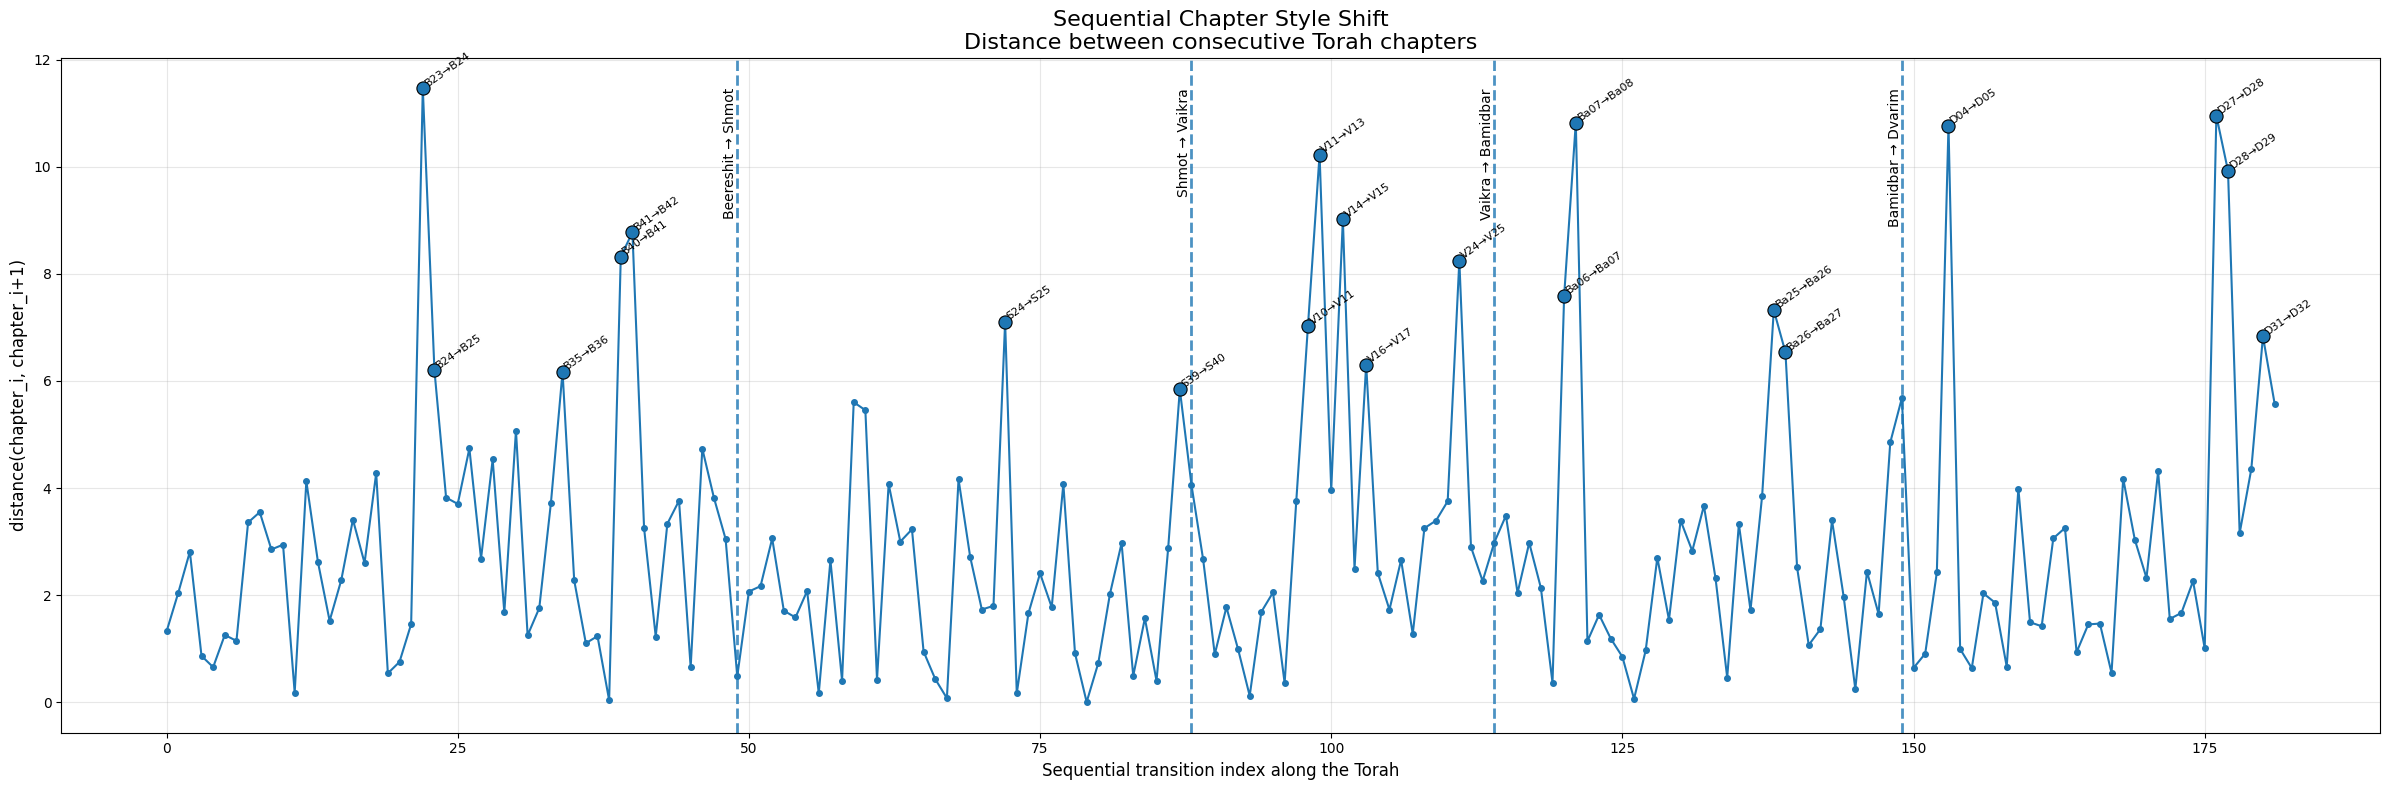

Top 20 sharpest sequential chapter transitions:


,transition_index,from_chapter,to_chapter,from_book,to_book,distance,is_book_boundary
0,22,Beereshit_CH23,Beereshit_CH24,Beereshit,Beereshit,11.465822,False
1,176,Dvarim_CH27,Dvarim_CH28,Dvarim,Dvarim,10.951836,False
2,121,Bamidbar_CH7,Bamidbar_CH8,Bamidbar,Bamidbar,10.824548,False
3,153,Dvarim_CH4,Dvarim_CH5,Dvarim,Dvarim,10.765941,False
4,99,Vaikra_CH11,Vaikra_CH13,Vaikra,Vaikra,10.227131,False
5,177,Dvarim_CH28,Dvarim_CH29,Dvarim,Dvarim,9.923159,False
6,101,Vaikra_CH14,Vaikra_CH15,Vaikra,Vaikra,9.014987,False
7,40,Beereshit_CH41,Beereshit_CH42,Beereshit,Beereshit,8.776118,False
8,39,Beereshit_CH40,Beereshit_CH41,Beereshit,Beereshit,8.319390,False
9,111,Vaikra_CH24,Vaikra_CH25,Vaikra,Vaikra,8.243586,False


All sequential transitions:


,transition_index,from_chapter,to_chapter,from_book,to_book,distance,is_book_boundary
0,0,Beereshit_CH1,Beereshit_CH2,Beereshit,Beereshit,1.322097,False
1,1,Beereshit_CH2,Beereshit_CH3,Beereshit,Beereshit,2.040560,False
2,2,Beereshit_CH3,Beereshit_CH4,Beereshit,Beereshit,2.810505,False
3,3,Beereshit_CH4,Beereshit_CH5,Beereshit,Beereshit,0.865587,False
4,4,Beereshit_CH5,Beereshit_CH6,Beereshit,Beereshit,0.655206,False
...,...,...,...,...,...,...,...
177,177,Dvarim_CH28,Dvarim_CH29,Dvarim,Dvarim,9.923159,False
178,178,Dvarim_CH29,Dvarim_CH30,Dvarim,Dvarim,3.156899,False
179,179,Dvarim_CH30,Dvarim_CH31,Dvarim,Dvarim,4.354189,False
180,180,Dvarim_CH31,Dvarim_CH32,Dvarim,Dvarim,6.830533,False


In [ ]:
# ============================================================
# Cell 8: Measures style-shift distance between consecutive chapters in Torah order and highlights the sharpest transitions.
# Keep the original execution order: run prerequisite cells first so shared variables are available.
# ============================================================

if "analysis_df" not in globals():
    raise RuntimeError("analysis_df was not found. Run cell 1 first.")

if "full_distance_matrix" not in globals():
    raise RuntimeError("full_distance_matrix was not found. Run cell 1 first.")

required_columns = ["chapter", "book"]

for col in required_columns:
    if col not in analysis_df.columns:
        raise RuntimeError(f"Column was not found {col} in analysis_df.")


import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


TORAH_BOOK_ORDER = [
    "Beereshit",
    "Shmot",
    "Vaikra",
    "Bamidbar",
    "Dvarim"
]

BOOK_ORDER_MAP = {
    book_name: index
    for index, book_name in enumerate(TORAH_BOOK_ORDER)
}

SEQUENTIAL_SHIFT_FIGSIZE = (24, 8)

TOP_N_SHARPEST_TRANSITIONS = 20

SHOW_TRANSITION_LABELS_ON_X_AXIS = False

MARK_TOP_TRANSITIONS_ON_GRAPH = True


def extract_chapter_number(chapter_name):
    """Helper function used by this cell."""

    chapter_name = str(chapter_name)

    match = re.search(r"_CH0*(\d+)", chapter_name)

    if match:
        return int(match.group(1))

    match = re.search(r"(\d+)", chapter_name)

    if match:
        return int(match.group(1))

    return 10**9


def short_transition_label(chapter_a, chapter_b):
    """Helper function used by this cell."""

    def short_chapter_label(chapter_name):
        chapter_name = str(chapter_name)

        if "_CH" in chapter_name:
            book_name, chapter_part = chapter_name.split("_CH", 1)

            chapter_digits = re.sub(r"\D", "", chapter_part)
            chapter_num = int(chapter_digits) if chapter_digits else 0

            short_book_map = {
                "Beereshit": "B",
                "Shmot": "S",
                "Vaikra": "V",
                "Bamidbar": "Ba",
                "Dvarim": "D"
            }

            short_book = short_book_map.get(book_name, book_name[:2])

            return f"{short_book}{chapter_num:02d}"

        return chapter_name[:8]

    return f"{short_chapter_label(chapter_a)}→{short_chapter_label(chapter_b)}"


ordered_df = analysis_df.copy()

ordered_df["original_index"] = ordered_df.index

ordered_df["book_order"] = ordered_df["book"].map(BOOK_ORDER_MAP)
ordered_df["chapter_number"] = ordered_df["chapter"].apply(extract_chapter_number)

ordered_df["book_order"] = ordered_df["book_order"].fillna(10**9)

ordered_df = (
    ordered_df
    .sort_values(["book_order", "chapter_number", "chapter"])
    .reset_index(drop=True)
)


transitions = []

for i in range(len(ordered_df) - 1):

    row_a = ordered_df.iloc[i]
    row_b = ordered_df.iloc[i + 1]

    original_index_a = int(row_a["original_index"])
    original_index_b = int(row_b["original_index"])

    distance_value = full_distance_matrix[original_index_a, original_index_b]

    is_book_boundary = row_a["book"] != row_b["book"]

    transitions.append({
        "transition_index": i,
        "from_chapter": row_a["chapter"],
        "to_chapter": row_b["chapter"],
        "from_book": row_a["book"],
        "to_book": row_b["book"],
        "from_chapter_number": row_a["chapter_number"],
        "to_chapter_number": row_b["chapter_number"],
        "distance": distance_value,
        "is_book_boundary": is_book_boundary,
        "transition_label": short_transition_label(row_a["chapter"], row_b["chapter"])
    })

transition_df = pd.DataFrame(transitions)


book_boundary_transitions = transition_df[
    transition_df["is_book_boundary"] == True
].copy()


plt.figure(figsize=SEQUENTIAL_SHIFT_FIGSIZE)

plt.plot(
    transition_df["transition_index"],
    transition_df["distance"],
    marker="o",
    linewidth=1.5,
    markersize=4
)

plt.title(
    "Sequential Chapter Style Shift\nDistance between consecutive Torah chapters",
    fontsize=16
)

plt.xlabel("Sequential transition index along the Torah", fontsize=12)
plt.ylabel("distance(chapter_i, chapter_i+1)", fontsize=12)

plt.grid(alpha=0.3)


for _, row in book_boundary_transitions.iterrows():

    x = row["transition_index"]

    plt.axvline(
        x=x,
        linestyle="--",
        linewidth=2,
        alpha=0.8
    )

    plt.text(
        x,
        transition_df["distance"].max(),
        f"{row['from_book']} → {row['to_book']}",
        rotation=90,
        va="top",
        ha="right",
        fontsize=10
    )


if MARK_TOP_TRANSITIONS_ON_GRAPH:

    top_transitions_for_graph = (
        transition_df
        .sort_values("distance", ascending=False)
        .head(TOP_N_SHARPEST_TRANSITIONS)
    )

    plt.scatter(
        top_transitions_for_graph["transition_index"],
        top_transitions_for_graph["distance"],
        s=90,
        edgecolors="black",
        linewidths=0.8,
        zorder=5
    )

    for _, row in top_transitions_for_graph.iterrows():

        plt.text(
            row["transition_index"],
            row["distance"],
            row["transition_label"],
            fontsize=8,
            rotation=35,
            ha="left",
            va="bottom"
        )


if SHOW_TRANSITION_LABELS_ON_X_AXIS:

    plt.xticks(
        ticks=transition_df["transition_index"],
        labels=transition_df["transition_label"],
        rotation=90,
        fontsize=5
    )

plt.tight_layout()
plt.show()


sharpest_transitions_df = (
    transition_df
    .sort_values("distance", ascending=False)
    .head(TOP_N_SHARPEST_TRANSITIONS)
    .reset_index(drop=True)
)

print(f"Top {TOP_N_SHARPEST_TRANSITIONS} sharpest sequential chapter transitions:")
display(
    sharpest_transitions_df[
        [
            "transition_index",
            "from_chapter",
            "to_chapter",
            "from_book",
            "to_book",
            "distance",
            "is_book_boundary"
        ]
    ]
)


print("All sequential transitions:")
display(
    transition_df[
        [
            "transition_index",
            "from_chapter",
            "to_chapter",
            "from_book",
            "to_book",
            "distance",
            "is_book_boundary"
        ]
    ]
)


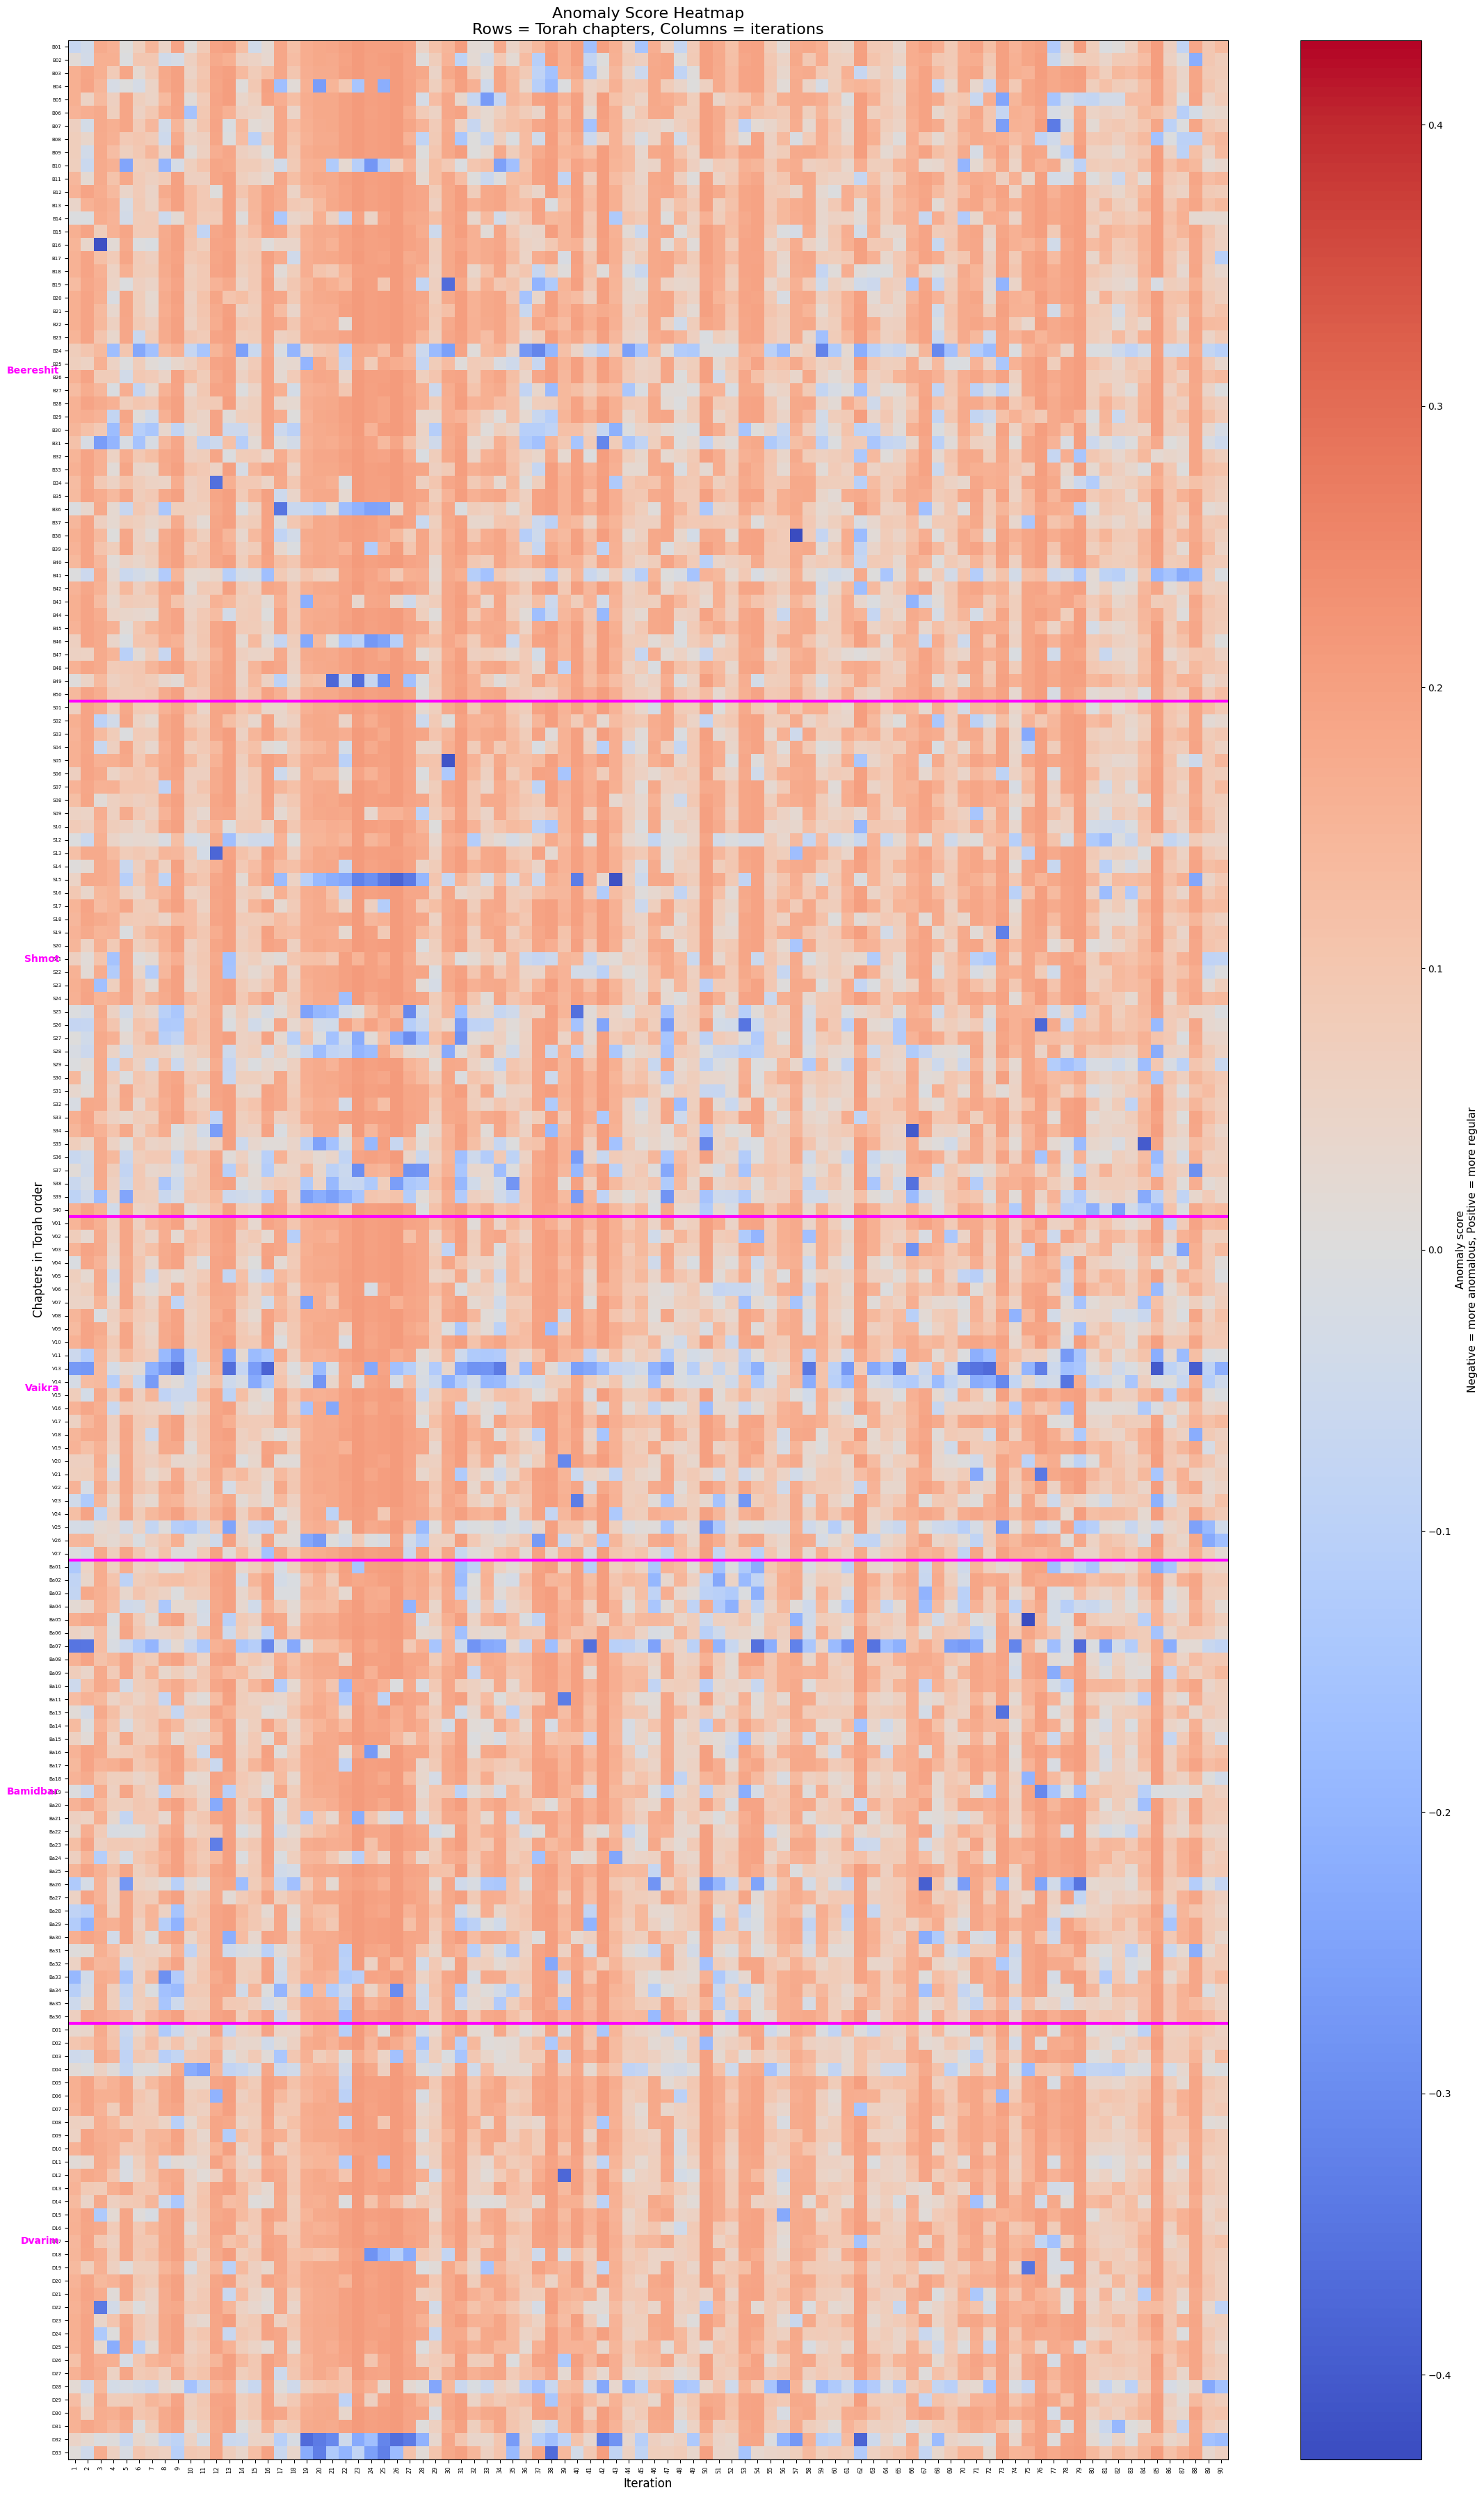

Helper table in Torah order:


,chapter,book,chapter_number,mean_anomaly_score,median_anomaly_score,min_anomaly_score,max_anomaly_score,negative_ratio
0,Beereshit_CH1,Beereshit,1,0.111726,0.147109,-0.161750,0.210719,0.100000
1,Beereshit_CH2,Beereshit,2,0.100651,0.095590,-0.216833,0.210642,0.111111
2,Beereshit_CH3,Beereshit,3,0.122001,0.156947,-0.156727,0.210447,0.077778
3,Beereshit_CH4,Beereshit,4,0.091281,0.102641,-0.260516,0.208698,0.144444
4,Beereshit_CH5,Beereshit,5,0.104920,0.131436,-0.263422,0.210788,0.155556
...,...,...,...,...,...,...,...,...
178,Dvarim_CH29,Dvarim,29,0.118191,0.112868,-0.138330,0.211083,0.033333
179,Dvarim_CH30,Dvarim,30,0.140477,0.170151,-0.025296,0.210890,0.033333
180,Dvarim_CH31,Dvarim,31,0.106757,0.121293,-0.190864,0.210091,0.088889
181,Dvarim_CH32,Dvarim,32,-0.022753,0.011013,-0.381758,0.199853,0.455556


Color interpretation:
- Negative-side colors = negative anomaly score = more anomalous chapter in that iteration.
- Positive-side colors = positive anomaly score = more typical chapter in that iteration.
- 0 is centered on the colorbar, making the transition between negative and positive values easier to see.


In [ ]:
# ============================================================
# Cell 9: Plots anomaly scores across iterations as a heatmap, ordered by Torah book and chapter.
# Keep the original execution order: run prerequisite cells first so shared variables are available.
# ============================================================

if "analysis_df" not in globals():
    raise RuntimeError("analysis_df was not found. Run cell 1 first.")

if "scores_df" not in globals():
    raise RuntimeError("scores_df was not found. Run cell 1 first.")

if "score_columns" not in globals():
    raise RuntimeError("score_columns was not found. Run cell 1 first.")


import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


TORAH_BOOK_ORDER = [
    "Beereshit",
    "Shmot",
    "Vaikra",
    "Bamidbar",
    "Dvarim"
]

BOOK_ORDER_MAP = {
    book_name: index
    for index, book_name in enumerate(TORAH_BOOK_ORDER)
}

ANOMALY_HEATMAP_FIGSIZE = (22, 36)
ANOMALY_Y_LABEL_FONT_SIZE = 5
ANOMALY_X_LABEL_FONT_SIZE = 6

SHOW_ALL_ITERATION_TICKS = True
MAX_X_TICKS_IF_SAMPLING = 25

SHOW_CHAPTER_NAMES = True

BOOK_SEPARATOR_COLOR = "magenta"
BOOK_SEPARATOR_LINEWIDTH = 3


def extract_chapter_number(chapter_name):
    """Helper function used by this cell."""

    chapter_name = str(chapter_name)

    match = re.search(r"_CH0*(\d+)", chapter_name)
    if match:
        return int(match.group(1))

    match = re.search(r"(\d+)", chapter_name)
    if match:
        return int(match.group(1))

    return 10**9


def short_chapter_label(chapter_name):
    """Helper function used by this cell."""

    chapter_name = str(chapter_name)

    if "_CH" in chapter_name:
        book_name, chapter_part = chapter_name.split("_CH", 1)

        chapter_digits = re.sub(r"\D", "", chapter_part)
        chapter_num = int(chapter_digits) if chapter_digits else 0

        short_book_map = {
            "Beereshit": "B",
            "Shmot": "S",
            "Vaikra": "V",
            "Bamidbar": "Ba",
            "Dvarim": "D"
        }

        short_book = short_book_map.get(book_name, book_name[:2])

        return f"{short_book}{chapter_num:02d}"

    return chapter_name[:10]


torah_order_df = analysis_df.copy()

torah_order_df["original_index"] = torah_order_df.index

torah_order_df["book_order"] = torah_order_df["book"].map(BOOK_ORDER_MAP)
torah_order_df["chapter_number"] = torah_order_df["chapter"].apply(extract_chapter_number)

torah_order_df["book_order"] = torah_order_df["book_order"].fillna(10**9)

torah_order_df = (
    torah_order_df
    .sort_values(["book_order", "chapter_number", "chapter"])
    .reset_index(drop=True)
)

torah_order_indices = torah_order_df["original_index"].to_numpy()


anomaly_matrix_sorted = scores_df.iloc[torah_order_indices].to_numpy()

chapter_labels_sorted = torah_order_df["chapter"].to_numpy()
short_chapter_labels_sorted = [
    short_chapter_label(ch)
    for ch in chapter_labels_sorted
]

iteration_labels = [str(col) for col in score_columns]


book_sizes = (
    torah_order_df
    .groupby("book", sort=False)
    .size()
)

book_boundaries = []
book_centers = []
book_names_for_plot = []

start_index = 0

for book_name, size in book_sizes.items():

    end_index = start_index + size
    center = start_index + (size - 1) / 2

    book_centers.append(center)
    book_names_for_plot.append(book_name)

    book_boundaries.append(end_index - 0.5)

    start_index = end_index


max_abs_score = np.nanmax(np.abs(anomaly_matrix_sorted))

if max_abs_score == 0:
    max_abs_score = 1.0

color_norm = TwoSlopeNorm(
    vmin=-max_abs_score,
    vcenter=0.0,
    vmax=max_abs_score
)


plt.figure(figsize=ANOMALY_HEATMAP_FIGSIZE)

im = plt.imshow(
    anomaly_matrix_sorted,
    aspect="auto",
    interpolation="nearest",
    norm=color_norm,
    cmap="coolwarm"
)

plt.title(
    "Anomaly Score Heatmap\nRows = Torah chapters, Columns = iterations",
    fontsize=16
)

plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Chapters in Torah order", fontsize=12)


n_iterations_local = anomaly_matrix_sorted.shape[1]

if SHOW_ALL_ITERATION_TICKS or n_iterations_local <= MAX_X_TICKS_IF_SAMPLING:
    x_ticks = np.arange(n_iterations_local)
    x_tick_labels = iteration_labels
else:
    x_ticks = np.linspace(0, n_iterations_local - 1, MAX_X_TICKS_IF_SAMPLING, dtype=int)
    x_tick_labels = [iteration_labels[i] for i in x_ticks]

plt.xticks(
    x_ticks,
    x_tick_labels,
    rotation=90,
    fontsize=ANOMALY_X_LABEL_FONT_SIZE
)


if SHOW_CHAPTER_NAMES:
    plt.yticks(
        np.arange(len(short_chapter_labels_sorted)),
        short_chapter_labels_sorted,
        fontsize=ANOMALY_Y_LABEL_FONT_SIZE
    )


cbar = plt.colorbar(im)
cbar.set_label(
    "Anomaly score\nNegative = more anomalous, Positive = more regular",
    fontsize=11
)


for boundary in book_boundaries[:-1]:
    plt.axhline(
        y=boundary,
        color=BOOK_SEPARATOR_COLOR,
        linewidth=BOOK_SEPARATOR_LINEWIDTH
    )


for center, book_name in zip(book_centers, book_names_for_plot):
    plt.text(
        x=-1.2,
        y=center,
        s=book_name,
        ha="right",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=BOOK_SEPARATOR_COLOR
    )


plt.tight_layout()
plt.show()


chapter_score_summary_df = torah_order_df[["chapter", "book", "chapter_number"]].copy()

chapter_score_summary_df["mean_anomaly_score"] = anomaly_matrix_sorted.mean(axis=1)
chapter_score_summary_df["median_anomaly_score"] = np.median(anomaly_matrix_sorted, axis=1)
chapter_score_summary_df["min_anomaly_score"] = anomaly_matrix_sorted.min(axis=1)
chapter_score_summary_df["max_anomaly_score"] = anomaly_matrix_sorted.max(axis=1)
chapter_score_summary_df["negative_ratio"] = (anomaly_matrix_sorted < 0).mean(axis=1)

print("Helper table in Torah order:")
display(
    chapter_score_summary_df.reset_index(drop=True)
)


print("Color interpretation:")
print("- Negative-side colors = negative anomaly score = more anomalous chapter in that iteration.")
print("- Positive-side colors = positive anomaly score = more typical chapter in that iteration.")
print("- 0 is centered on the colorbar, making the transition between negative and positive values easier to see.")
